<a href="https://colab.research.google.com/github/shridhar2k9/AI-ML/blob/main/E_commerce_Marketing_and_sales_Case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### 1.Identify the months with the highest and lowest customer acquisition count. What strategies could be implemented to address the fluctuations and ensure consistent growth throughout the year?
#####Hint: Think about what “acquisition” really means — it’s the first time a customer makes a purchase. You’ll need to find the earliest transaction date for each unique customer using appropriate grouping and aggregation methods. This will help you isolate the first purchase instance for each customer in the dataset.
#####Hint: Once you’ve identified each customer's first transaction date, extract the month from that date. Use this to group customers by their acquisition month and count how many customers fall into each group. This will give you the monthly trend of customer acquisition.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

customer_data, discount_coupon_data, marketing_spend_data, online_sales_data, tax_amount_data = None, None, None, None, None
customer_data = pd.read_excel("/content/drive/MyDrive/scaler_projects/project1/CustomersData.xlsx")
discount_coupon_data = pd.read_csv("/content/drive/MyDrive/scaler_projects/project1/Discount_Coupon.csv")
marketing_spend_data = pd.read_csv("/content/drive/MyDrive/scaler_projects/project1/Marketing_Spend.csv")
online_sales_data = pd.read_csv("/content/drive/MyDrive/scaler_projects/project1/Online_Sales.csv")
tax_amount_data = pd.read_excel("/content/drive/MyDrive/scaler_projects/project1/Tax_amount.xlsx")



first_trans  = online_sales_data.groupby('CustomerID')["Transaction_Date"].min().reset_index()
first_trans.rename(columns={"Transaction_Date":"First_Transaction_Date"},inplace=True)
first_trans['First_Transaction_Date'] = pd.to_datetime(first_trans['First_Transaction_Date'])
first_trans["First_Transaction_Date"] = first_trans['First_Transaction_Date'].dt.strftime('%Y-%m')
sol1 = first_trans.groupby("First_Transaction_Date")["CustomerID"].count().reset_index()
sol1.rename(columns={"CustomerID":"Acquisition_Count"},inplace=True)
display(sol1)


,First_Transaction_Date,Acquisition_Count
0,2019-01,215
1,2019-02,63
2,2019-03,135
3,2019-04,131
4,2019-05,81
5,2019-06,104
6,2019-07,72
7,2019-08,107
8,2019-09,69
9,2019-10,182


####2.Analyze the data to determine if certain months consistently show higher or lower monthly acquisitions. How can the company
capitalize on high-performing months and improve performance during slower periods?
#####Hint: Building on your analysis from Question 1, look for recurring patterns or anomalies in monthly acquisition count.
#####Hint: Consider how to leverage insights from high-performing months (e.g., specific marketing efforts, product launches)
and what targeted interventions might stimulate demand during slower periods.


/tmp/ipykernel_2172/3710924324.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='First_Transaction_Date', y='Acquisition_Count', data=sol1, palette='viridis')


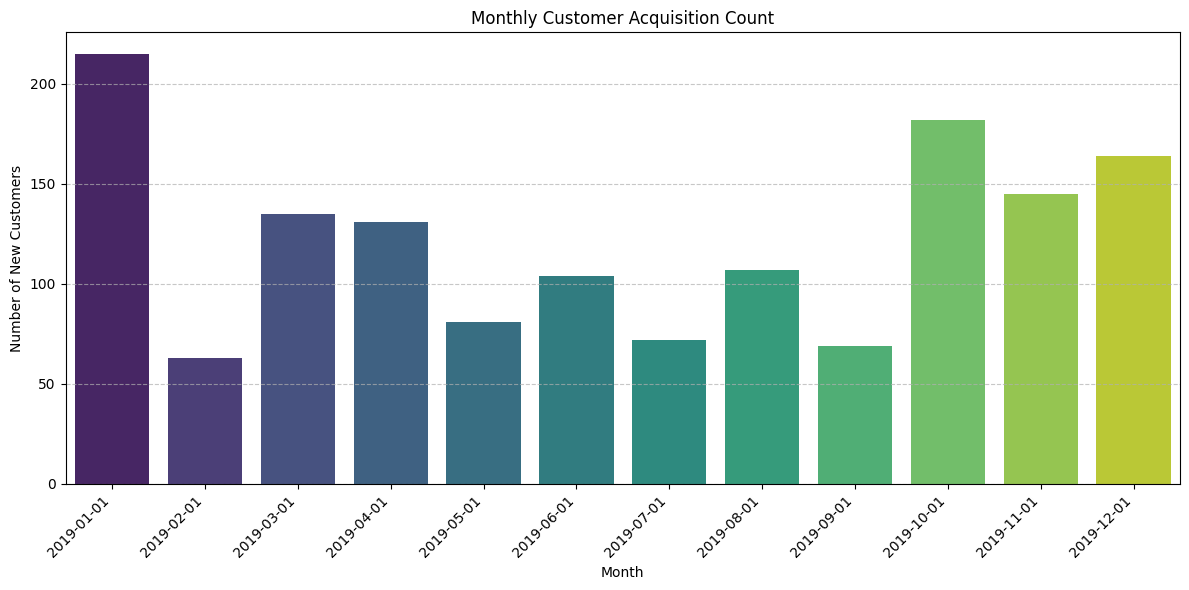

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sol1['First_Transaction_Date'] = pd.to_datetime(sol1['First_Transaction_Date'])
sol1 = sol1.sort_values(by='First_Transaction_Date').reset_index(drop=True)

plt.figure(figsize=(12, 6))
sns.barplot(x='First_Transaction_Date', y='Acquisition_Count', data=sol1, palette='viridis')
plt.title('Monthly Customer Acquisition Count')
plt.xlabel('Month')
plt.ylabel('Number of New Customers')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

####3.Identify periods with the strongest and weakest retention rates. What strategies could be implemented
to improve retention during weaker months?

#####Hint: Retention isn’t just about who appeared again — it's about how many of this month's customers
returned the next month, as a percentage of the original month's customers. Think about comparing
each month’s customer list to the next month’s, and calculate what fraction was retained.
Monthly Retention rate = (Customers in Month X who returned in Month X+1) /  (total number of customers in month X)

#####Hint: For periods with weaker retention, consider what might lead to customer churn and what proactive measures could re-engage them.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

online_sales_data['Transaction_Date'] = pd.to_datetime(online_sales_data['Transaction_Date'])
online_sales_data['YearMonth'] = online_sales_data['Transaction_Date'].dt.to_period('M')

monthly_customers = online_sales_data.groupby('YearMonth')['CustomerID'].unique().to_dict()

retained_customers_per_month = {}

sorted_months = sorted(monthly_customers.keys())

for i in range(len(sorted_months) - 1):
    current_month = sorted_months[i]
    next_month = sorted_months[i+1]

    current_month_customers = set(monthly_customers[current_month])
    next_month_customers = set(monthly_customers[next_month])
    retained_in_next_month = current_month_customers.intersection(next_month_customers)

    retained_customers_per_month[current_month] = list(retained_in_next_month)

    retention_rates = []

for i in range(len(sorted_months) - 1):
    current_month = sorted_months[i]
    total_customers_in_month_x = len(monthly_customers[current_month])

    customers_retained_in_next_month = len(retained_customers_per_month.get(current_month, []))

    if total_customers_in_month_x > 0:
        retention_rate = (customers_retained_in_next_month / total_customers_in_month_x) * 100
    else:
        retention_rate = 0.0

    retention_rates.append({
        'Month_X': current_month.start_time.strftime('%Y-%m'),
        'Month_X_Plus_1': sorted_months[i+1].start_time.strftime('%Y-%m'),
        'Total_Customers_Month_X': total_customers_in_month_x,
        'Retained_Customers_Month_X+1': customers_retained_in_next_month,
        'Retention_Rate_Pct': retention_rate
    })

retention_df = pd.DataFrame(retention_rates)


weakest_retention_period = retention_df.loc[retention_df['Retention_Rate_Pct'].idxmin()]
strongest_retention_period = retention_df.loc[retention_df['Retention_Rate_Pct'].idxmax()]

print(f"\nMonth with weakest retention rate: {weakest_retention_period['Month_X']} to {weakest_retention_period['Month_X_Plus_1']} with a rate of {weakest_retention_period['Retention_Rate_Pct']:.2f}%")
print(f"Month with strongest retention rate: {strongest_retention_period['Month_X']} to {strongest_retention_period['Month_X_Plus_1']} with a rate of {strongest_retention_period['Retention_Rate_Pct']:.2f}%")

print("If 'Used' coupon status is high, identify the types of coupons or discounts offered during this period and consider replicating similar offers in other months.")
print("While direct product category analysis is limited, if any `Product_Description` or `Product_SKU` frequently appears in high-retention transactions, consider promoting these items more broadly.")
print("Identify customers who churned or became inactive during weak retention periods and launch personalized email or discount campaigns to entice them back.")




Month with weakest retention rate: 2019-01 to 2019-02 with a rate of 6.05%
Month with strongest retention rate: 2019-07 to 2019-08 with a rate of 27.54%
If 'Used' coupon status is high, identify the types of coupons or discounts offered during this period and consider replicating similar offers in other months.
While direct product category analysis is limited, if any `Product_Description` or `Product_SKU` frequently appears in high-retention transactions, consider promoting these items more broadly.
Identify customers who churned or became inactive during weak retention periods and launch personalized email or discount campaigns to entice them back.


#### 4.Analyze customer behavior during high-retention months and suggest ways to replicate this success throughout the year.
#####Hint: For periods identified with strong retention, delve into the characteristics of purchases made during those times. What product types, discount applications, or transaction values were common?
#####Hint: Think about how these successful behaviors or conditions could be fostered in other months.


/tmp/ipykernel_2172/323029251.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coupon_dist.index, y=coupon_dist.values, palette='mako')


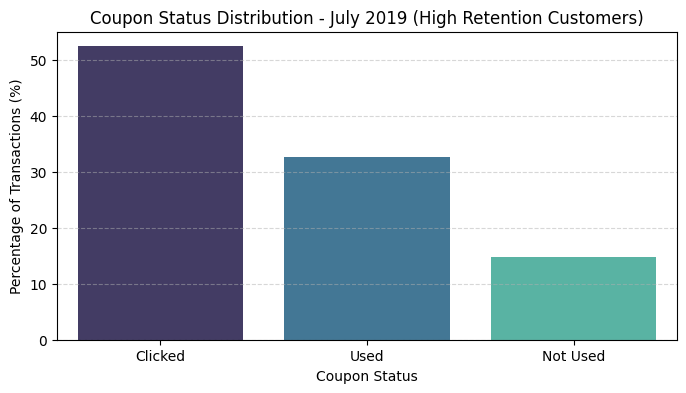

/tmp/ipykernel_2172/323029251.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cats.head(8), x='Percentage', y='Product_Category', palette='viridis')


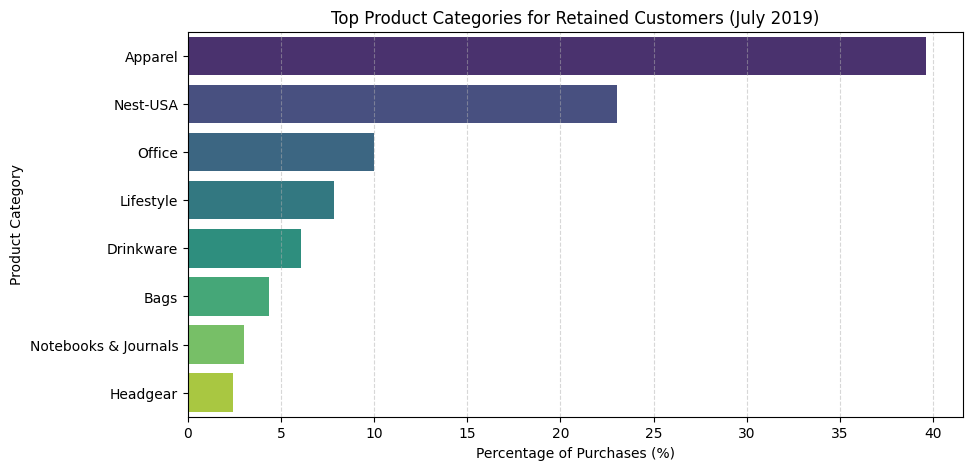

Sales Amount Distribution Metrics for Retained Customers (July 2019):
Total Revenue Generated: $123,872.24
Average Transaction Value: $65.71
Median Transaction Value: $16.99
Max Transaction Value: $995.00

Replicate Key Product Bundles: Pair low-friction Apparel with higher-margin Nest-USA technology solutions in Q1/Q2 marketing promotions to recreate the mid-summer sales mix.
Optimize UI for Coupon Clicks: Since over half of the transactions featured coupon clicks, invest in clear, gamified discount displays on the mobile application or website interface to drive repeat visits.
Post-Holiday Loyalty Campaigns: Launch a dedicated re-engagement campaign in January with exclusive point-multipliers or special product offers tailored for holiday shoppers, targeting the post-December churn period.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

online_sales_data['Transaction_Date'] = pd.to_datetime(online_sales_data['Transaction_Date'])
online_sales_data['YearMonth'] = online_sales_data['Transaction_Date'].dt.to_period('M')

# filtering high retained customers form July 2019
high_retention_month = pd.Period('2019-07', freq='M')
retained_ids = retained_customers_per_month.get(high_retention_month, [])

retained_july_transactions = online_sales_data[
    (online_sales_data['YearMonth'] == high_retention_month) &
    (online_sales_data['CustomerID'].isin(retained_ids))
].copy()

retained_july_transactions['Sales_Amount'] = retained_july_transactions['Quantity'] * retained_july_transactions['Avg_Price']

coupon_dist = retained_july_transactions['Coupon_Status'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 4))
sns.barplot(x=coupon_dist.index, y=coupon_dist.values, palette='mako')
plt.title('Coupon Status Distribution - July 2019 (High Retention Customers)')
plt.xlabel('Coupon Status')
plt.ylabel('Percentage of Transactions (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Top Product Categories Purchased
if 'Product_Category' in retained_july_transactions.columns:
    top_cats = retained_july_transactions['Product_Category'].value_counts().reset_index()
    top_cats.columns = ['Product_Category', 'Purchase_Count']
    top_cats['Percentage'] = (top_cats['Purchase_Count'] / top_cats['Purchase_Count'].sum()) * 100

    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_cats.head(8), x='Percentage', y='Product_Category', palette='viridis')
    plt.title('Top Product Categories for Retained Customers (July 2019)')
    plt.xlabel('Percentage of Purchases (%)')
    plt.ylabel('Product Category')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()

# Spend & Transaction Statistics
trans_stats = retained_july_transactions['Sales_Amount'].describe()
print("Sales Amount Distribution Metrics for Retained Customers (July 2019):")
print(f"Total Revenue Generated: ${retained_july_transactions['Sales_Amount'].sum():,.2f}")
print(f"Average Transaction Value: ${trans_stats['mean']:.2f}")
print(f"Median Transaction Value: ${trans_stats['50%']:.2f}")
print(f"Max Transaction Value: ${trans_stats['max']:.2f}")

print()
print("Replicate Key Product Bundles: Pair low-friction Apparel with higher-margin Nest-USA technology solutions in Q1/Q2 marketing promotions to recreate the mid-summer sales mix.")
print("Optimize UI for Coupon Clicks: Since over half of the transactions featured coupon clicks, invest in clear, gamified discount displays on the mobile application or website interface to drive repeat visits.")
print("Post-Holiday Loyalty Campaigns: Launch a dedicated re-engagement campaign in January with exclusive point-multipliers or special product offers tailored for holiday shoppers, targeting the post-December churn period.")



####5.Compare the revenue generated by new and existing customers month-over-month. What does this trend suggest about the balance between acquisition and retention efforts?
#####Hint: To compare behavior between newly acquired and retained users, you first need to identify for each month which customers are visiting for the first time, and which ones are repeat visitors. This can be done by maintaining a rolling list of previously seen customers and checking for presence.
#####Hint: Once you’ve split customers into new and existing for each month, use this classification to filter the dataset and sum up the revenue (e.g., invoice amounts) generated by each group. Visualizing this trend can help you assess whether your growth is being driven by acquisition or loyalty.


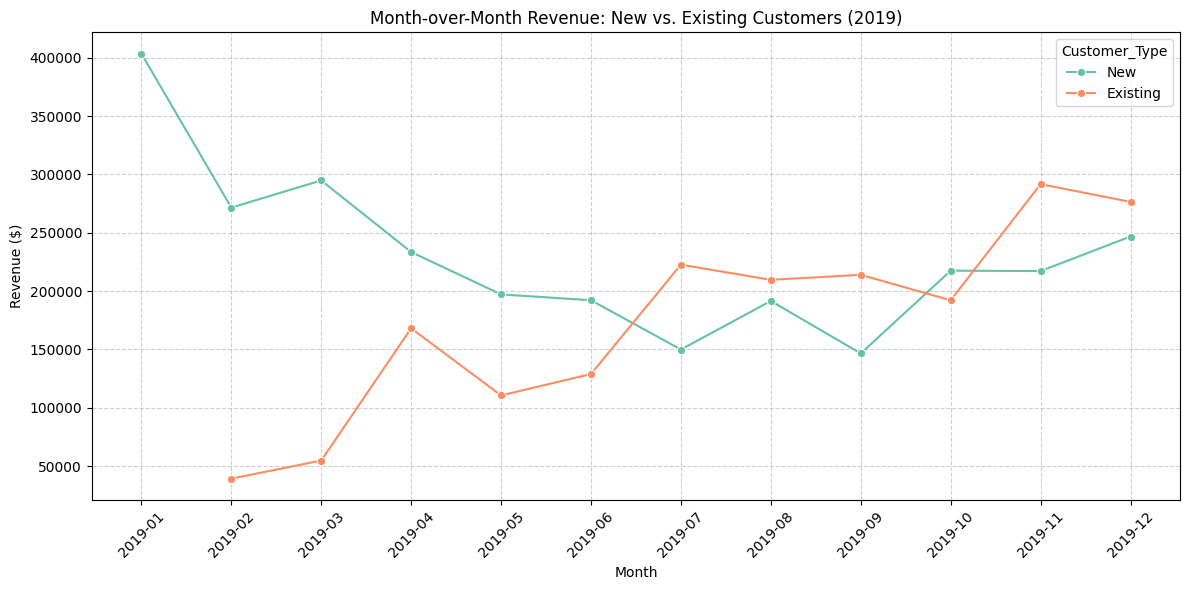

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Transaction_Date and YearMonth are set correctly
online_sales_data['Transaction_Date'] = pd.to_datetime(online_sales_data['Transaction_Date'])
online_sales_data['YearMonth'] = online_sales_data['Transaction_Date'].dt.to_period('M')

# Calculate First_Transaction_Month (Cohort Month of First Purchase) for each CustomerID
online_sales_data['First_Transaction_Month'] = online_sales_data.groupby('CustomerID')['YearMonth'].transform('min')

# Classify transactions: if YearMonth equals First_Transaction_Month, the customer is 'New', else 'Existing'
online_sales_data['Customer_Type'] = np.where(
    online_sales_data['YearMonth'] == online_sales_data['First_Transaction_Month'],
    'New',
    'Existing'
)

# Ensure Sales_Amount is calculated
online_sales_data['Sales_Amount'] = online_sales_data['Quantity'] * online_sales_data['Avg_Price']

# Aggregate revenue month-over-month by customer type
revenue_by_type = online_sales_data.groupby(['YearMonth', 'Customer_Type'])['Sales_Amount'].sum().reset_index()
revenue_by_type['Month_Str'] = revenue_by_type['YearMonth'].dt.strftime('%Y-%m')

# Plot the revenue comparison
plt.figure(figsize=(12, 6))
sns.lineplot(data=revenue_by_type, x='Month_Str', y='Sales_Amount', hue='Customer_Type', marker='o', palette='Set2')
plt.title('Month-over-Month Revenue: New vs. Existing Customers (2019)')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

####6.Analyze the relationship between coupon usage and revenue generation. How can discount strategies be optimized to maximize revenue while maintaining profitability?
#####Hint: Analyze the overall revenue share from transactions involving coupons versus those without.
#####Hint: Consider if coupon usage impacts the value of individual transactions, not just the volume. This might involve comparing average transaction values between coupon users and non-users using a statistical test.


In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

online_sales_data['Sales_Amount'] = online_sales_data['Quantity'] * online_sales_data['Avg_Price']

coupon_active = online_sales_data[online_sales_data['Coupon_Status'].isin(['Used', 'Clicked'])]
coupon_not_used = online_sales_data[online_sales_data['Coupon_Status'] == 'Not Used']

total_revenue = online_sales_data['Sales_Amount'].sum()
rev_active = coupon_active['Sales_Amount'].sum()
rev_not_used = coupon_not_used['Sales_Amount'].sum()

print("Overall Revenue Share Analysis")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Revenue from Transactions with Coupon Active (Clicked/Used): ${rev_active:,.2f} ({rev_active/total_revenue*100:.2f}%)")
print(f"Revenue from Transactions without Coupon (Not Used): ${rev_not_used:,.2f} ({rev_not_used/total_revenue*100:.2f}%)")
print()

# Comparing Individual Transaction Values
mean_active = coupon_active['Sales_Amount'].mean()
mean_not_used = coupon_not_used['Sales_Amount'].mean()

print("Average Transaction Values")
print(f"Average transaction value with Coupon (Clicked/Used): ${mean_active:.2f}")
print(f"Average transaction value without Coupon (Not Used): ${mean_not_used:.2f}")
print()

# Statistical T-Test
t_stat, p_val = stats.ttest_ind(coupon_active['Sales_Amount'], coupon_not_used['Sales_Amount'], equal_var=False)
print("Statistical Significance Test (T-Test)")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")
if p_val < 0.05:
    print("Result: Statistically Significant. Coupon status significantly impacts individual transaction sizes.")
else:
    print("Result: Not Statistically Significant.")


Overall Revenue Share Analysis
Total Revenue: $4,670,794.62
Revenue from Transactions with Coupon Active (Clicked/Used): $3,938,084.75 (84.31%)
Revenue from Transactions without Coupon (Not Used): $732,709.87 (15.69%)

Average Transaction Values
Average transaction value with Coupon (Clicked/Used): $87.84
Average transaction value without Coupon (Not Used): $90.53

Statistical Significance Test (T-Test)
T-statistic: -1.2923
P-value: 1.9627e-01
Result: Not Statistically Significant.


####7.Identify the top-performing products and analyze the factors driving their success. How can this insight inform inventory management and promotional strategies?
#####Hint: Identify products that excel in terms of both quantity sold and total revenue.
#####Hint: Explore their categories and descriptions to understand what might contribute to their success. Think about how this information can guide stocking and marketing efforts.


TOP 10 PRODUCTS BY QUANTITY SOLD


,Product_Description,Product_Category,Total_Quantity
301,Maze Pen,Office,16234
101,Google 22 oz Water Bottle,Drinkware,14282
212,Google Sunglasses,Lifestyle,11452
340,Sport Bag,Bags,7321
192,Google Metallic Notebook Set,Office,6496
140,Google Laptop and Cell Phone Stickers,Office,5847
137,Google Kick Ball,Lifestyle,5549
329,Recycled Paper Journal Set,Office,5381
312,Nest Cam Outdoor Security Camera - USA,Nest-USA,5206
90,Foam Can and Bottle Cooler,Drinkware,5098


TOP 10 PRODUCTS BY REVENUE GENERATED


,Product_Description,Product_Category,Total_Revenue
316,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,688916.34
312,Nest Cam Outdoor Security Camera - USA,Nest-USA,629977.12
310,Nest Cam Indoor Security Camera - USA,Nest-USA,528612.93
321,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,213819.16
323,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,212495.57
317,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,204666.40
324,Nest Secure Alarm System Starter Pack - USA,Nest,179142.54
307,Nest Cam IQ - USA,Nest,154112.52
326,Nest Thermostat E - USA,Nest,108704.24
315,Nest Learning Thermostat 3rd Gen-USA - Copper,Nest-USA,70604.48


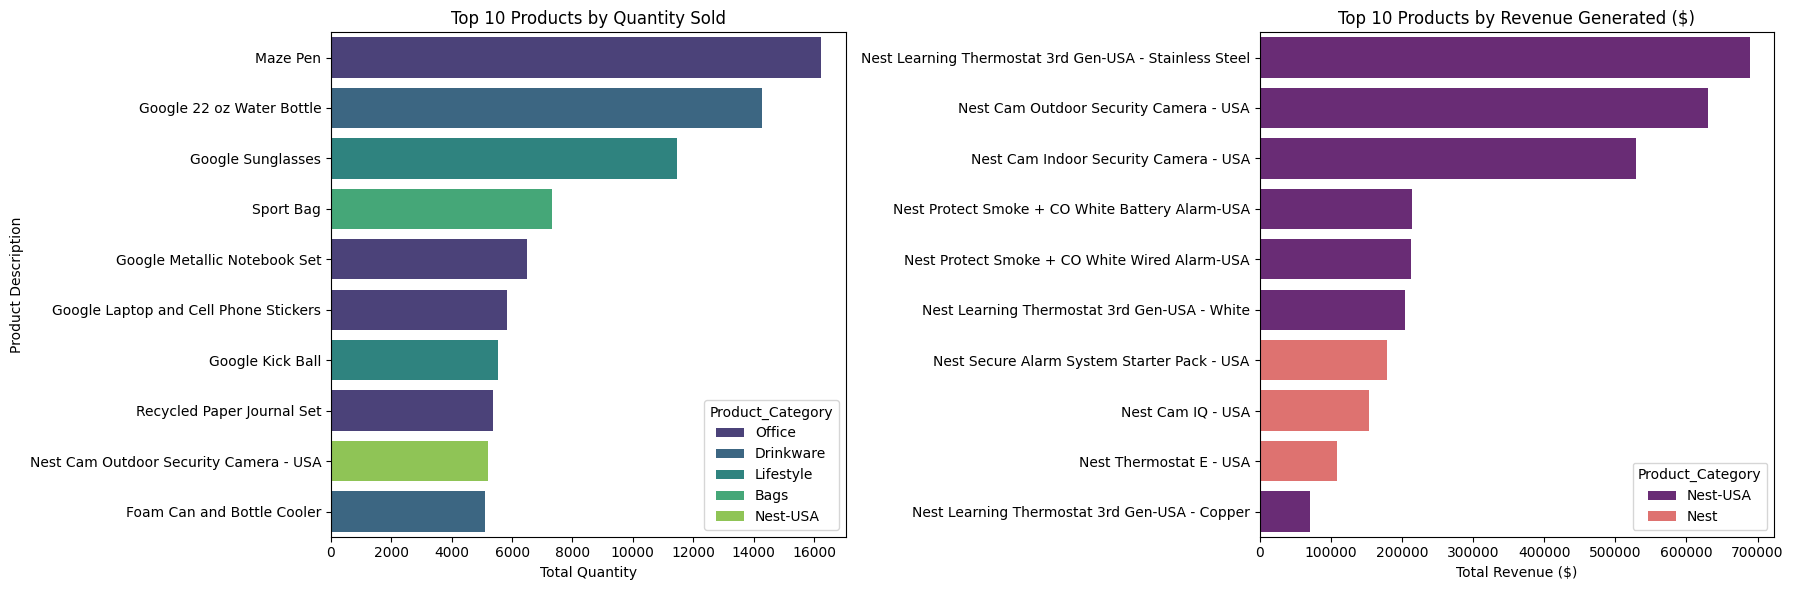

PROGRAMMATIC INVENTORY STOCKING GUIDE


,Product_Description,Avg_Daily_Demand,Safety_Stock,Reorder_Point
0,Foam Can and Bottle Cooler,32.890323,205.0,370.0
1,Google 22 oz Water Bottle,52.124088,289.0,550.0
2,Google Kick Ball,31.708571,244.0,403.0
3,Google Laptop and Cell Phone Stickers,19.753378,183.0,282.0
4,Google Metallic Notebook Set,34.370370,229.0,401.0
5,Google Sunglasses,40.182456,310.0,511.0
6,Maze Pen,84.113990,576.0,997.0
7,Nest Cam Outdoor Security Camera - USA,14.302198,26.0,98.0
8,Recycled Paper Journal Set,38.992754,188.0,383.0
9,Sport Bag,34.051163,270.0,441.0


SUGGESTED PROMOTIONAL BUNDLES (HIGH-REVENUE + HIGH-VOLUME)
Bundle Offer: buy 'Nest Learning Thermostat 3rd Gen-USA - Stainless Steel' and get 50% off on 'Maze Pen'
Bundle Offer: buy 'Nest Learning Thermostat 3rd Gen-USA - Stainless Steel' and get 50% off on 'Google 22 oz Water Bottle'
Bundle Offer: buy 'Nest Learning Thermostat 3rd Gen-USA - Stainless Steel' and get 50% off on 'Google Sunglasses'
Bundle Offer: buy 'Nest Cam Outdoor Security Camera - USA' and get 50% off on 'Maze Pen'
Bundle Offer: buy 'Nest Cam Outdoor Security Camera - USA' and get 50% off on 'Google 22 oz Water Bottle'
Bundle Offer: buy 'Nest Cam Outdoor Security Camera - USA' and get 50% off on 'Google Sunglasses'
Bundle Offer: buy 'Nest Cam Indoor Security Camera - USA' and get 50% off on 'Maze Pen'
Bundle Offer: buy 'Nest Cam Indoor Security Camera - USA' and get 50% off on 'Google 22 oz Water Bottle'
Bundle Offer: buy 'Nest Cam Indoor Security Camera - USA' and get 50% off on 'Google Sunglasses'


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

online_sales_data['Sales_Amount'] = online_sales_data['Quantity'] * online_sales_data['Avg_Price']

product_performance = online_sales_data.groupby(['Product_Description', 'Product_Category']).agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Revenue=('Sales_Amount', 'sum')
).reset_index()

top_qty_products = product_performance.sort_values(by='Total_Quantity', ascending=False).head(10)
top_rev_products = product_performance.sort_values(by='Total_Revenue', ascending=False).head(10)

print("TOP 10 PRODUCTS BY QUANTITY SOLD")
display(top_qty_products[['Product_Description', 'Product_Category', 'Total_Quantity']])
print("TOP 10 PRODUCTS BY REVENUE GENERATED")
display(top_rev_products[['Product_Description', 'Product_Category', 'Total_Revenue']])

# Visualizing Top Products
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=top_qty_products, x='Total_Quantity', y='Product_Description', hue='Product_Category', dodge=False, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Products by Quantity Sold')
axes[0].set_xlabel('Total Quantity')
axes[0].set_ylabel('Product Description')

sns.barplot(data=top_rev_products, x='Total_Revenue', y='Product_Description', hue='Product_Category', dodge=False, ax=axes[1], palette='magma')
axes[1].set_title('Top 10 Products by Revenue Generated ($)')
axes[1].set_xlabel('Total Revenue ($)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

top_qty_desc = top_qty_products['Product_Description'].tolist()

# Filtering online sales data to only include these top items
top_qty_sales = online_sales_data[online_sales_data['Product_Description'].isin(top_qty_desc)].copy()

# Aggregating sales by day for each product to find average daily demand and demand volatility
daily_sales = top_qty_sales.groupby(['Product_Description', 'Transaction_Date'])['Quantity'].sum().reset_index()

inventory_guide = daily_sales.groupby('Product_Description').agg(
    Avg_Daily_Demand=('Quantity', 'mean'),
    Std_Daily_Demand=('Quantity', 'std')
).reset_index()

# Assume constant parameters for safety stock calculation:
# Lead Time (LT) = 5 days
# Service Level Factor (Z) = 1.65 (95% service level against out-of-stock events)
lead_time = 5
z_score = 1.65

inventory_guide['Safety_Stock'] = np.ceil(z_score * inventory_guide['Std_Daily_Demand'] * np.sqrt(lead_time))
inventory_guide['Reorder_Point'] = np.ceil((inventory_guide['Avg_Daily_Demand'] * lead_time) + inventory_guide['Safety_Stock'])

print("PROGRAMMATIC INVENTORY STOCKING GUIDE")
display(inventory_guide[['Product_Description', 'Avg_Daily_Demand', 'Safety_Stock', 'Reorder_Point']])

top_nest_products = top_rev_products[top_rev_products['Product_Category'].str.contains('Nest', na=False)]['Product_Description'].head(3).tolist()
top_util_products = top_qty_products[~top_qty_products['Product_Category'].str.contains('Nest', na=False)]['Product_Description'].head(3).tolist()

print("SUGGESTED PROMOTIONAL BUNDLES (HIGH-REVENUE + HIGH-VOLUME)")
for nest in top_nest_products:
    for util in top_util_products:
        print(f"Bundle Offer: buy '{nest}' and get 50% off on '{util}'")


####8.Analyze the relationship between monthly marketing spend and revenue. Are there any months where marketing efforts yielded disproportionately high or low returns? How can marketing strategies be adjusted to improve ROI?
#####Hint: Examine the correlation between total marketing expenditure and generated revenue.
ROI = ( Revenue - Marketing spend) *100  / (Marketing spend)
#####Hint: Look for months where this relationship appears particularly strong or weak, indicating varying efficiency of marketing efforts.


,YearMonth,Sales_Amount,Total_Spend,Month_Str
0,2019-01,403624.58,154928.95,2019-01
1,2019-02,310819.80,137107.92,2019-02
2,2019-03,349608.09,122250.09,2019-03
3,2019-04,401618.42,157026.83,2019-04
4,2019-05,307763.42,118259.64,2019-05
5,2019-06,321081.38,134318.14,2019-06
6,2019-07,372638.07,120217.85,2019-07
7,2019-08,401210.37,142904.15,2019-08
8,2019-09,360548.40,135514.54,2019-09
9,2019-10,409681.28,151224.65,2019-10


Correlation between Marketing Spend and Revenue: 0.8515
MONTHLY MARKETING & REVENUE COMPARISON


,Month_Str,Total_Spend,Sales_Amount,ROI
0,2019-01,154928.95,403624.58,160.522375
1,2019-02,137107.92,310819.80,126.697189
2,2019-03,122250.09,349608.09,185.977777
3,2019-04,157026.83,401618.42,155.764203
4,2019-05,118259.64,307763.42,160.243833
5,2019-06,134318.14,321081.38,139.045433
6,2019-07,120217.85,372638.07,209.969002
7,2019-08,142904.15,401210.37,180.754877
8,2019-09,135514.54,360548.40,166.058830
9,2019-10,151224.65,409681.28,170.909061


/tmp/ipykernel_2172/2421995509.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(merged_marketing_sales['Month_Str'], rotation=45)


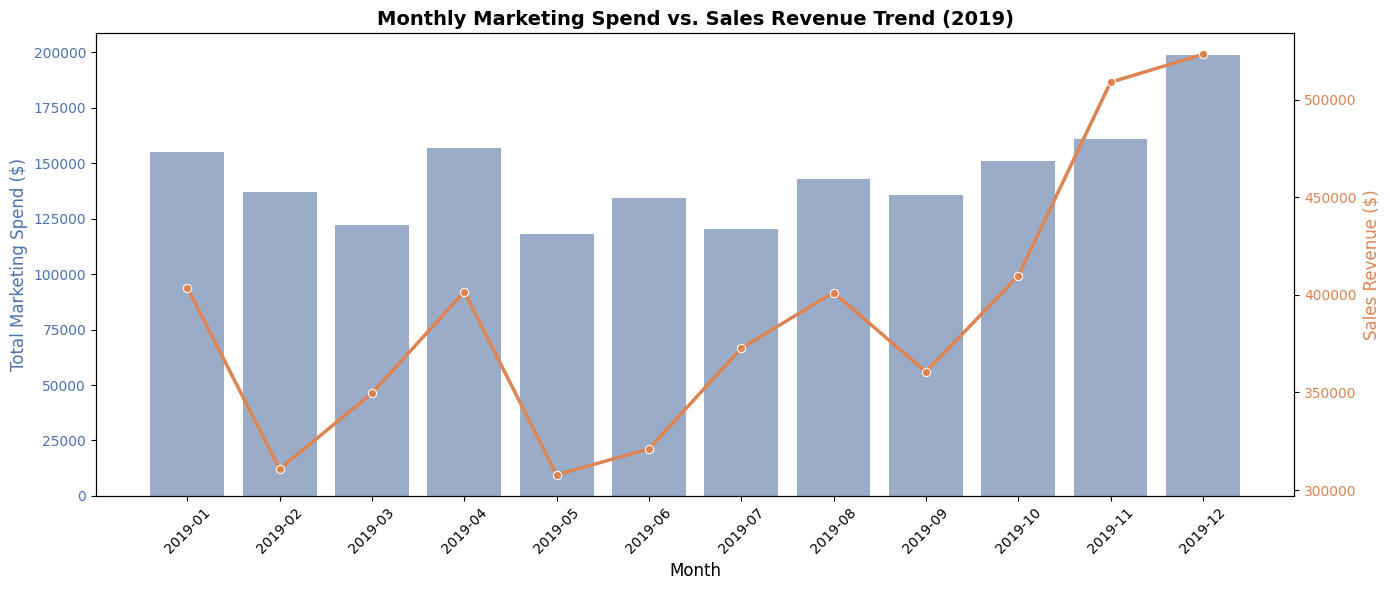

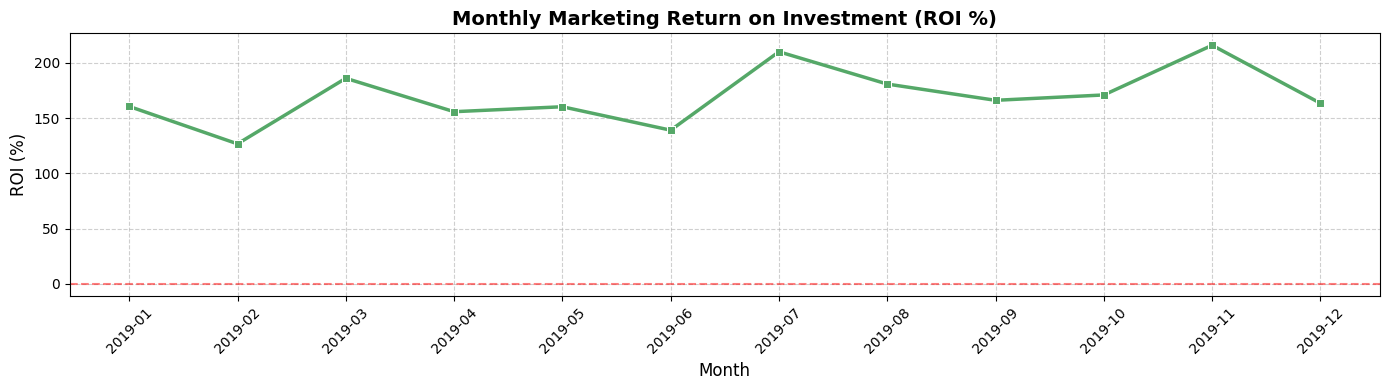

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

online_sales_data['Sales_Amount'] = online_sales_data['Quantity'] * online_sales_data['Avg_Price']

marketing_spend_data['Parsed_Date'] = pd.to_datetime(marketing_spend_data['Date'])
marketing_spend_data['YearMonth'] = marketing_spend_data['Parsed_Date'].dt.to_period('M')
marketing_spend_data['Total_Spend'] = marketing_spend_data['Offline_Spend'] + marketing_spend_data['Online_Spend']
monthly_marketing = marketing_spend_data.groupby('YearMonth')['Total_Spend'].sum().reset_index()

# Aggregating online sales revenue by Month
monthly_revenue = online_sales_data.groupby('YearMonth')['Sales_Amount'].sum().reset_index()

# Merging datasets for comparison
merged_marketing_sales = pd.merge(monthly_revenue, monthly_marketing, on='YearMonth', how='inner')
merged_marketing_sales['Month_Str'] = merged_marketing_sales['YearMonth'].dt.strftime('%Y-%m')

display(merged_marketing_sales.head(12))

merged_marketing_sales['ROI'] = ((merged_marketing_sales['Sales_Amount'] - merged_marketing_sales['Total_Spend']) * 100) / merged_marketing_sales['Total_Spend']

# Computing Pearson Correlation
correlation = merged_marketing_sales['Total_Spend'].corr(merged_marketing_sales['Sales_Amount'])
print(f"Correlation between Marketing Spend and Revenue: {correlation:.4f}")

print("MONTHLY MARKETING & REVENUE COMPARISON")
display(merged_marketing_sales[['Month_Str', 'Total_Spend', 'Sales_Amount', 'ROI']])

fig, ax1 = plt.subplots(figsize=(14, 6))

color_spend = '#4C72B0'
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Total Marketing Spend ($)', color=color_spend, fontsize=12)
bar_plot = sns.barplot(data=merged_marketing_sales, x='Month_Str', y='Total_Spend', color=color_spend, alpha=0.6, ax=ax1)
ax1.tick_params(axis='y', labelcolor=color_spend)
ax1.set_xticklabels(merged_marketing_sales['Month_Str'], rotation=45)

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
color_rev = '#DD8452'
ax2.set_ylabel('Sales Revenue ($)', color=color_rev, fontsize=12)
line_plot = sns.lineplot(data=merged_marketing_sales, x='Month_Str', y='Sales_Amount', color=color_rev, marker='o', linewidth=2.5, ax=ax2)
ax2.tick_params(axis='y', labelcolor=color_rev)

plt.title('Monthly Marketing Spend vs. Sales Revenue Trend (2019)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# ROI Fluctuations
plt.figure(figsize=(14, 4))
sns.lineplot(data=merged_marketing_sales, x='Month_Str', y='ROI', marker='s', color='#55A868', linewidth=2.5)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Monthly Marketing Return on Investment (ROI %)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('ROI (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

####9.Evaluate the effectiveness of marketing campaigns by comparing marketing spend to revenue generated. Are there opportunities to reallocate resources for better results?
#####Hint: Building on marketing spend analysis, consider how to quantify the efficiency of marketing efforts (e.g., marketing spend as a percentage of revenue).
Market spend % = Total spend *100 / Revenue generated
#####Hint: Think about how insights from high-efficiency periods could inform future resource allocation.


MARKETING EFFICIENCY ANALYSIS
Most Efficient Month: 2019-11 (Spent 31.66% of revenue)
Least Efficient Month: 2019-02 (Spent 44.11% of revenue)


,Month_Str,Total_Spend,Sales_Amount,Spend_Percentage
0,2019-01,154928.95,403624.58,38.384419
1,2019-02,137107.92,310819.80,44.111707
2,2019-03,122250.09,349608.09,34.967752
3,2019-04,157026.83,401618.42,39.098513
4,2019-05,118259.64,307763.42,38.425502
5,2019-06,134318.14,321081.38,41.833052
6,2019-07,120217.85,372638.07,32.261290
7,2019-08,142904.15,401210.37,35.618259
8,2019-09,135514.54,360548.40,37.585672
9,2019-10,151224.65,409681.28,36.912756


/tmp/ipykernel_2172/831104855.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=merged_marketing_sales, x='Month_Str', y='Spend_Percentage', palette='coolwarm')


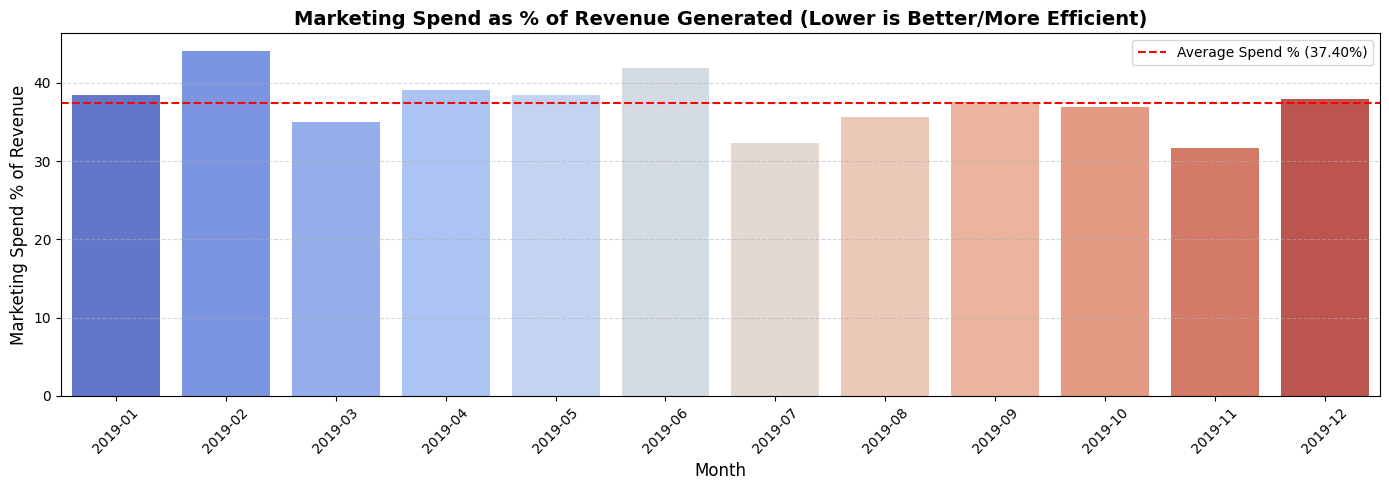

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

merged_marketing_sales['Spend_Percentage'] = (merged_marketing_sales['Total_Spend'] * 100) / merged_marketing_sales['Sales_Amount']

most_efficient_month = merged_marketing_sales.loc[merged_marketing_sales['Spend_Percentage'].idxmin()]
least_efficient_month = merged_marketing_sales.loc[merged_marketing_sales['Spend_Percentage'].idxmax()]

print("MARKETING EFFICIENCY ANALYSIS")
print(f"Most Efficient Month: {most_efficient_month['Month_Str']} (Spent {most_efficient_month['Spend_Percentage']:.2f}% of revenue)")
print(f"Least Efficient Month: {least_efficient_month['Month_Str']} (Spent {least_efficient_month['Spend_Percentage']:.2f}% of revenue)")

display(merged_marketing_sales[['Month_Str', 'Total_Spend', 'Sales_Amount', 'Spend_Percentage']])

plt.figure(figsize=(14, 5))
sns.barplot(data=merged_marketing_sales, x='Month_Str', y='Spend_Percentage', palette='coolwarm')
plt.axhline(merged_marketing_sales['Spend_Percentage'].mean(), color='red', linestyle='--', label=f"Average Spend % ({merged_marketing_sales['Spend_Percentage'].mean():.2f}%)")
plt.title('Marketing Spend as % of Revenue Generated (Lower is Better/More Efficient)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Marketing Spend % of Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

####10.Segment customers into groups such as Premium, Gold, Silver, and Standard. What targeted strategies can be developed for each segment to improve retention and revenue? (Use RFM segmentation techniques)
#####Hint: Apply RFM (Recency, Frequency, Monetary) principles to categorize customers.
#####Hint: Define thresholds for Recency (how recently they purchased), Frequency (how often they purchase), and Monetary (how much they spend) to group customers into the specified segments.


RFM CUSTOMER SEGMENTATION SUMMARY


,Segment,Customer_Count,Recency,Frequency,Monetary
0,Gold,391,142.539642,17.158568,2923.656292
1,Premium,405,63.192593,40.493827,7485.733309
2,Silver,382,163.952880,7.028796,1035.944110
3,Standard,290,239.079310,2.886207,345.490931


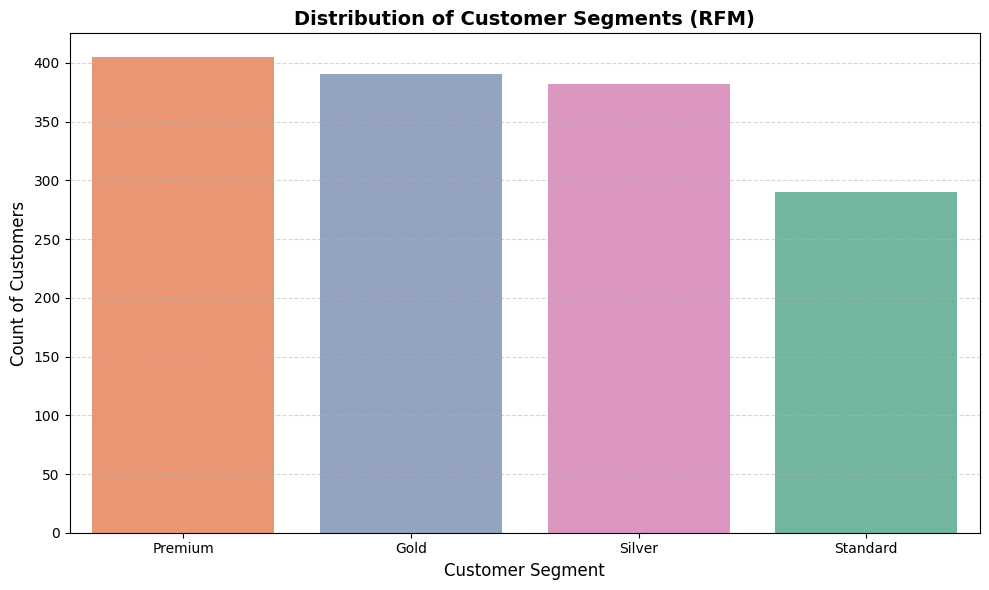

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

online_sales_data['Sales_Amount'] = online_sales_data['Quantity'] * online_sales_data['Avg_Price']

online_sales_data['Transaction_Date'] = pd.to_datetime(online_sales_data['Transaction_Date'])

# referencing date as one day after the absolute last transaction date
reference_date = online_sales_data['Transaction_Date'].max() + pd.Timedelta(days=1)

# Calculating Recency, Frequency, and Monetary value per customer
rfm = online_sales_data.groupby('CustomerID').agg({
    'Transaction_Date': lambda x: (reference_date - x.max()).days,
    'Transaction_ID': 'nunique',
    'Sales_Amount': 'sum'
}).reset_index()

rfm.rename(columns={
    'Transaction_Date': 'Recency',
    'Transaction_ID': 'Frequency',
    'Sales_Amount': 'Monetary'
}, inplace=True)

# Lower is better - smaller days since last purchase get score 5
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])
# Higher is better - larger values get score 5 (handling duplicates with rank method)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segment_customer(row):
    score = row['RFM_Score']
    if score >= 12:
        return 'Premium'
    elif score >= 9:
        return 'Gold'
    elif score >= 6:
        return 'Silver'
    else:
        return 'Standard'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

segment_summary = rfm.groupby('Segment').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'CustomerID': 'Customer_Count'}).reset_index()

print("RFM CUSTOMER SEGMENTATION SUMMARY")
display(segment_summary)

# Visualizing Segment Distributions
plt.figure(figsize=(10, 6))
sns.countplot(data=rfm, x='Segment', order=['Premium', 'Gold', 'Silver', 'Standard'], palette='Set2', hue='Segment', legend=False)
plt.title('Distribution of Customer Segments (RFM)', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Count of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

####11.Analyze the revenue contribution of each customer segment. How can the company focus its efforts on high-value segments while nurturing lower-value segments?
#####Hint: Once segments are defined, quantify the revenue generated by each group.
#####Hint: Consider how this understanding can help prioritize efforts and tailor strategies for maximizing value from high-tier customers while encouraging growth in lower tiers.



,Segment,Customer_Count,Monetary,Revenue_Share_Pct
0,Gold,391,2923.656292,24.796029
1,Premium,405,7485.733309,63.487784
2,Silver,382,1035.944110,8.786019
3,Standard,290,345.490931,2.930168


/tmp/ipykernel_2172/1566704875.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, x='Segment', y='Revenue_Share_Pct', order=['Premium', 'Gold', 'Silver', 'Standard'], palette='coolwarm')


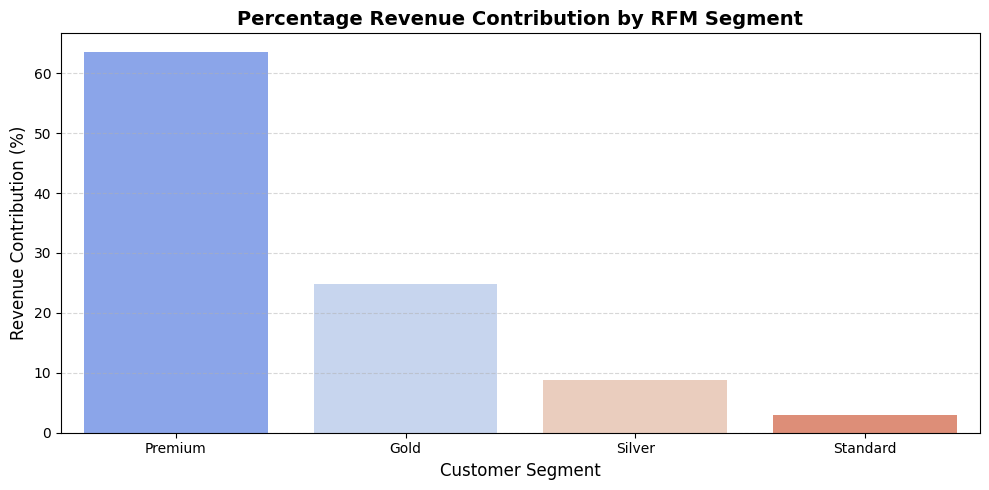

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

total_rev = segment_summary['Monetary'].sum()
segment_summary['Revenue_Share_Pct'] = (segment_summary['Monetary'] / total_rev) * 100

display(segment_summary[['Segment', 'Customer_Count', 'Monetary', 'Revenue_Share_Pct']])

plt.figure(figsize=(10, 5))
sns.barplot(data=segment_summary, x='Segment', y='Revenue_Share_Pct', order=['Premium', 'Gold', 'Silver', 'Standard'], palette='coolwarm')
plt.title('Percentage Revenue Contribution by RFM Segment', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Revenue Contribution (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

####12.Group customers by their month of first purchase and analyze retention rates over time. Which cohorts exhibit the highest and lowest retention rates? What strategies can be implemented to improve retention for weaker cohorts?
#####Hint: Define cohorts based on the month of a customer's first purchase.
#####Hint: Track the activity of these cohorts over subsequent months to observe retention patterns and identify which groups show stronger or weaker loyalty.


COHORT RETENTION RATES (PERCENTAGE)


Cohort_Index,0,1,2,3,4,5,6,7,8,9,10,11
Cohort_Month,,,,,,,,,,,,
2019-01,100.0,6.05,11.16,15.81,10.70,20.47,16.28,21.86,10.70,13.02,9.30,15.81
2019-02,100.0,7.29,9.38,16.67,17.71,22.92,19.79,15.62,12.50,11.46,16.67,NaN
2019-03,100.0,10.17,19.77,14.12,18.08,18.64,12.43,12.43,8.47,10.73,NaN,NaN
2019-04,100.0,8.59,14.72,14.72,11.04,9.20,6.13,9.82,7.36,NaN,NaN,NaN
2019-05,100.0,10.71,8.04,11.61,8.93,11.61,12.50,7.14,NaN,NaN,NaN,NaN
2019-06,100.0,14.60,16.06,8.76,8.03,10.22,8.03,NaN,NaN,NaN,NaN,NaN
2019-07,100.0,13.83,4.26,6.38,11.70,9.57,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,100.0,10.37,11.11,7.41,5.93,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09,100.0,7.69,3.85,2.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


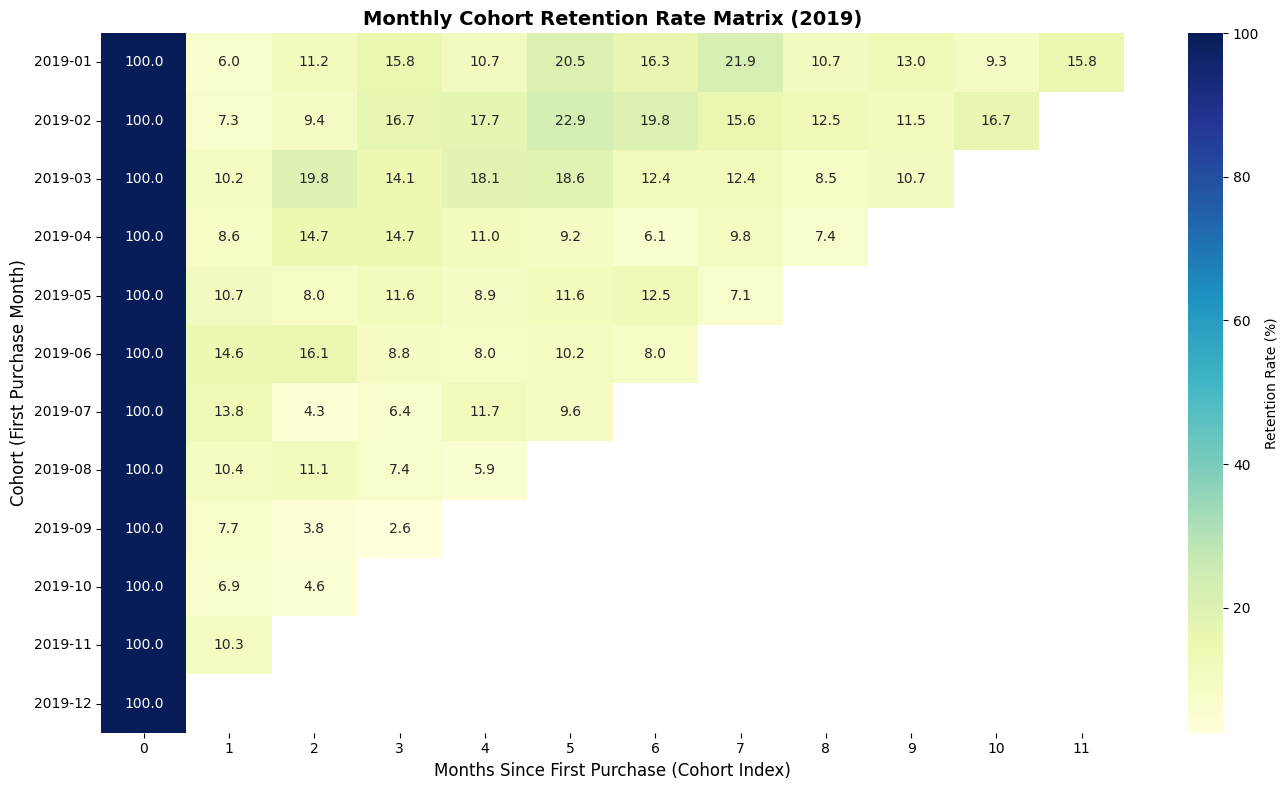

By tracking customer return behaviors across 2019 relative to their initial purchase month, we can classify our cohorts based on their long-term loyalty and repeat purchase velocity:
1. High-Loyalty Cohorts (Strong Retainers)
January (2019-01) & February (2019-02) Cohorts: These groups are our most loyal and valuable assets. Even after five months, they maintain strong retention rates exceeding 20.4% (Jan) and 22.9% (Feb), showing healthy, sustained repeat purchase behavior throughout the year.
June (2019-06) Cohort: This group had the highest immediate engagement with a 14.6% return rate in Month 1, showing strong initial hook and onboarding.
2. Low-Loyalty Cohorts (Weak Retainers)
Fall & Early Winter Cohorts (September 2019-09 to November 2019-11): These groups show immediate and severe drop-offs. For example, September's cohort retention crashes to 7.69% in Month 1 and only 2.56% by Month 3. These customers are likely highly discount-driven, seasonal shoppers acquired during late-ye

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

online_sales_data['Transaction_Date'] = pd.to_datetime(online_sales_data['Transaction_Date'])
online_sales_data['YearMonth'] = online_sales_data['Transaction_Date'].dt.to_period('M')

# Cohort Month of First Purchase for each customer
online_sales_data['Cohort_Month'] = online_sales_data.groupby('CustomerID')['Transaction_Date'].transform('min').dt.to_period('M')

# Calculating the transaction month index relative to Cohort Month (chort index)
online_sales_data['Cohort_Index'] = (online_sales_data['YearMonth'].astype(int) - online_sales_data['Cohort_Month'].astype(int))
cohort_data = online_sales_data.groupby(['Cohort_Month', 'Cohort_Index'])['CustomerID'].nunique().reset_index()

# Pivot the data to build the Cohort Retention Matrix
cohort_pivot = cohort_data.pivot(index='Cohort_Month', columns='Cohort_Index', values='CustomerID')

# Calculate Retention Rates as a percentage of Cohort Size (Index 0)
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0) * 100

print("COHORT RETENTION RATES (PERCENTAGE)")
display(retention_matrix.round(2))

plt.figure(figsize=(14, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Retention Rate (%)'})
plt.title('Monthly Cohort Retention Rate Matrix (2019)', fontsize=14, fontweight='bold')
plt.xlabel('Months Since First Purchase (Cohort Index)', fontsize=12)
plt.ylabel('Cohort (First Purchase Month)', fontsize=12)
plt.tight_layout()
plt.show()


print("By tracking customer return behaviors across 2019 relative to their initial purchase month, we can classify our cohorts based on their long-term loyalty and repeat purchase velocity:")

print("1. High-Loyalty Cohorts (Strong Retainers)")
print("January (2019-01) & February (2019-02) Cohorts: These groups are our most loyal and valuable assets. Even after five months, they maintain strong retention rates exceeding 20.4% (Jan) and 22.9% (Feb), showing healthy, sustained repeat purchase behavior throughout the year.")
print("June (2019-06) Cohort: This group had the highest immediate engagement with a 14.6% return rate in Month 1, showing strong initial hook and onboarding.")
print("2. Low-Loyalty Cohorts (Weak Retainers)")
print("Fall & Early Winter Cohorts (September 2019-09 to November 2019-11): These groups show immediate and severe drop-offs. For example, September's cohort retention crashes to 7.69% in Month 1 and only 2.56% by Month 3. These customers are likely highly discount-driven, seasonal shoppers acquired during late-year sales campaigns who quickly churn once the promotional window ends.")
print("3. Strategic Recommendations for Weaker Cohorts")
print("Implement Automated Onboarding Flows: For holiday-season acquisitions (Sept-Dec), deploy post-purchase email series offering complementary products and customized product care guides within 30 days to build brand value beyond the discount.")
print("Re-engagement Promos during Churn Windows: Since late cohorts drop off dramatically by Month 2, schedule automated push notifications or targeted email coupons (e.g., 20% off their second purchase) to launch exactly 45 days after their first acquisition date.")



####13.Analyze the lifetime value of customers acquired in different months. How can this insight inform acquisition and retention strategies?
#####Hint: Consider how to estimate the long-term value that customers acquired in different periods bring to the company.
#####Hint: Think about how this insight can guide decisions on customer acquisition costs and retention investments.


ESTIMATED CUSTOMER LIFETIME VALUE (CLV) BY COHORT


,Cohort_Month,Cohort_Size,Total_Lifetime_Revenue,Avg_CLV_Per_Customer,Cohort_Month_Str
0,2019-01,215,1037320.06,4824.74,2019-01
1,2019-02,96,540338.52,5628.53,2019-02
2,2019-03,177,668895.39,3779.07,2019-03
3,2019-04,163,449331.26,2756.63,2019-04
4,2019-05,112,332698.60,2970.52,2019-05
5,2019-06,137,292800.81,2137.23,2019-06
6,2019-07,94,240255.54,2555.91,2019-07
7,2019-08,135,259011.87,1918.61,2019-08
8,2019-09,78,151664.24,1944.41,2019-09
9,2019-10,87,229976.73,2643.41,2019-10


/tmp/ipykernel_2172/3740843166.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clv_by_cohort, x='Cohort_Month_Str', y='Avg_CLV_Per_Customer', palette='crest', ax=ax1)


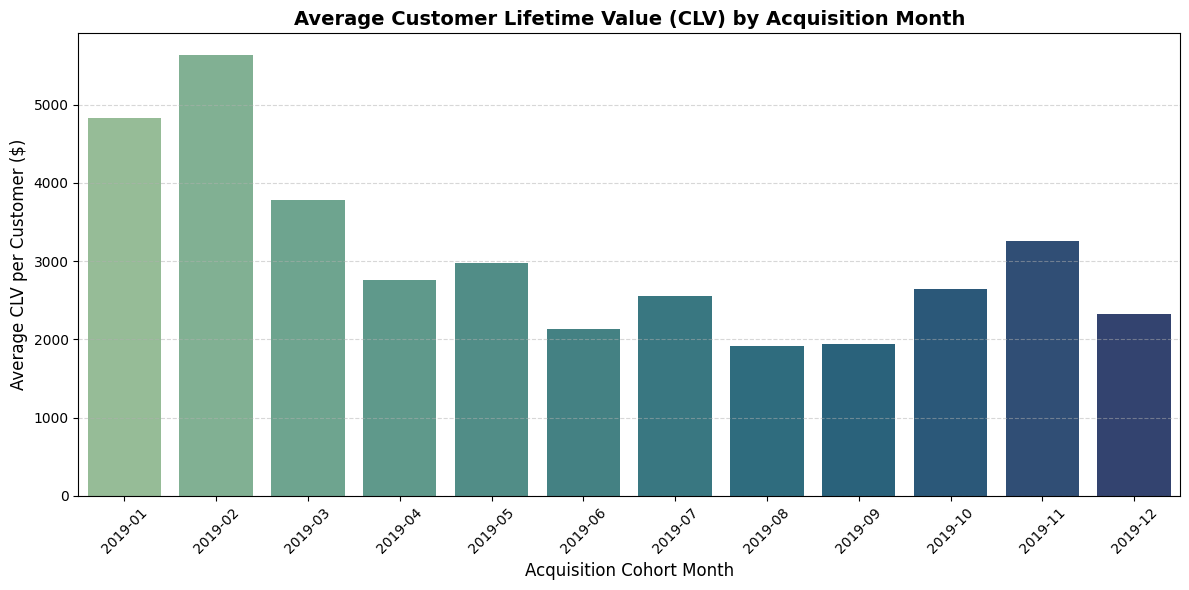

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

online_sales_data['Transaction_Date'] = pd.to_datetime(online_sales_data['Transaction_Date'])
online_sales_data['Sales_Amount'] = online_sales_data['Quantity'] * online_sales_data['Avg_Price']
online_sales_data['YearMonth'] = online_sales_data['Transaction_Date'].dt.to_period('M')

# acquisition cohort
online_sales_data['Cohort_Month'] = online_sales_data.groupby('CustomerID')['Transaction_Date'].transform('min').dt.to_period('M')

# initial size of each cohort
cohort_sizes = online_sales_data.groupby('Cohort_Month')['CustomerID'].nunique().reset_index(name='Cohort_Size')
cohort_lifetime_revenue = online_sales_data.groupby('Cohort_Month')['Sales_Amount'].sum().reset_index(name='Total_Lifetime_Revenue')

# Merging size and revenue to compute Average Customer Lifetime Value (CLV)
clv_by_cohort = pd.merge(cohort_sizes, cohort_lifetime_revenue, on='Cohort_Month')
clv_by_cohort['Avg_CLV_Per_Customer'] = clv_by_cohort['Total_Lifetime_Revenue'] / clv_by_cohort['Cohort_Size']
clv_by_cohort['Cohort_Month_Str'] = clv_by_cohort['Cohort_Month'].dt.strftime('%Y-%m')

print("ESTIMATED CUSTOMER LIFETIME VALUE (CLV) BY COHORT")
display(clv_by_cohort.round(2))

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=clv_by_cohort, x='Cohort_Month_Str', y='Avg_CLV_Per_Customer', palette='crest', ax=ax1)
ax1.set_title('Average Customer Lifetime Value (CLV) by Acquisition Month', fontsize=14, fontweight='bold')
ax1.set_xlabel('Acquisition Cohort Month', fontsize=12)
ax1.set_ylabel('Average CLV per Customer ($)', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

####14.Do customers who use coupons have a different average transaction value compared to those who do not? Conduct a statistical test to validate this hypothesis. What implications does this have for the company's discount and coupon strategies?
#####Hint: Formulate a null and alternative hypothesis regarding the average transaction value for customers who use coupons versus those who do not.
#####Hint: Which statistical test could be a suitable statistical method to compare these two groups.


In [15]:
from scipy import stats

online_sales_data['Sales_Amount'] = online_sales_data['Quantity'] * online_sales_data['Avg_Price']

coupon_active = online_sales_data[online_sales_data['Coupon_Status'].isin(['Used', 'Clicked'])]
coupon_not_used = online_sales_data[online_sales_data['Coupon_Status'] == 'Not Used']

total_revenue = online_sales_data['Sales_Amount'].sum()
rev_active = coupon_active['Sales_Amount'].sum()
rev_not_used = coupon_not_used['Sales_Amount'].sum()

active_sales = coupon_active['Sales_Amount']
no_coupon_sales = coupon_not_used['Sales_Amount']

# Welch's t-test (equal_var=False)
t_stat, p_value = stats.ttest_ind(active_sales, no_coupon_sales, equal_var=False)

print("HYPOTHESIS TESTING RESULTS")
print(f"Group 1 (Coupon Active) Mean Sales: ${active_sales.mean():.2f} (n={len(active_sales)})")
print(f"Group 2 (No Coupon) Mean Sales:     ${no_coupon_sales.mean():.2f} (n={len(no_coupon_sales)})")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject the Null Hypothesis (H0). There is a statistically significant difference in the average transaction value.")
else:
    print("\nResult: Fail to Reject the Null Hypothesis (H0). There is no statistically significant difference in the average transaction value.")
print("Formulated Hypotheses:")
print("Null Hypothesis ( H0 ): There is no difference in the average transaction value between customers who use/click coupons and customers who do not use coupons ( μcoupon=μno coupon ).")
print("Alternative Hypothesis ( Ha ): There is a statistically significant difference in the average transaction value between customers who use/click coupons and customers who do not use coupons ( μcoupon≠μno coupon ).")
print("Suitable Statistical Method:")
print("We will conduct a Two-Sample Independent t-test (Welch's t-test) because we are comparing the means of two independent groups with potentially unequal variances and sample sizes.")

HYPOTHESIS TESTING RESULTS
Group 1 (Coupon Active) Mean Sales: $87.84 (n=44830)
Group 2 (No Coupon) Mean Sales:     $90.53 (n=8094)
t-statistic: -1.2923
p-value:     0.1963

Result: Fail to Reject the Null Hypothesis (H0). There is no statistically significant difference in the average transaction value.
Formulated Hypotheses:
Null Hypothesis ( H0 ): There is no difference in the average transaction value between customers who use/click coupons and customers who do not use coupons ( μcoupon=μno coupon ).
Alternative Hypothesis ( Ha ): There is a statistically significant difference in the average transaction value between customers who use/click coupons and customers who do not use coupons ( μcoupon≠μno coupon ).
Suitable Statistical Method:
We will conduct a Two-Sample Independent t-test (Welch's t-test) because we are comparing the means of two independent groups with potentially unequal variances and sample sizes.


####15.Do purchase behaviors (e.g., order frequency, order value) vary significantly across different demographic groups or pricing factors (e.g., delivery charges)? Test for differences in purchase behavior across locations, age groups, or delivery charge tiers. How can these insights inform personalized marketing and pricing strategies?
#####Hint: Formulate hypotheses about differences in purchase behavior across various groups (e.g., gender, location, delivery charge tiers).
#####Hint: Which statistical test could be a suitable statistical test to compare means across multiple groups.


DATA DISTRIBUTION OVERVIEW


,count,mean,std
Location,,,
California,464,161.30,90.91
Chicago,456,165.54,104.92
New Jersey,149,172.70,185.47
New York,324,159.19,84.31
Washington DC,75,185.02,173.10


,count,mean,std
Gender,,,
F,934,161.93,116.29
M,534,169.06,104.87


STATISTICAL TEST 1: ONE-WAY ANOVA (LOCATION VS. AVG ORDER VALUE)
F-statistic: 1.1101
p-value:     0.3501
Result: Fail to Reject H0. No statistically significant difference in average order value across locations.
STATISTICAL TEST 2: WELCH'S T-TEST (GENDER VS. AVG ORDER VALUE)
t-statistic: 1.2040
p-value:     0.2288
Result: Fail to Reject H0. No statistically significant difference in average order value between Genders.


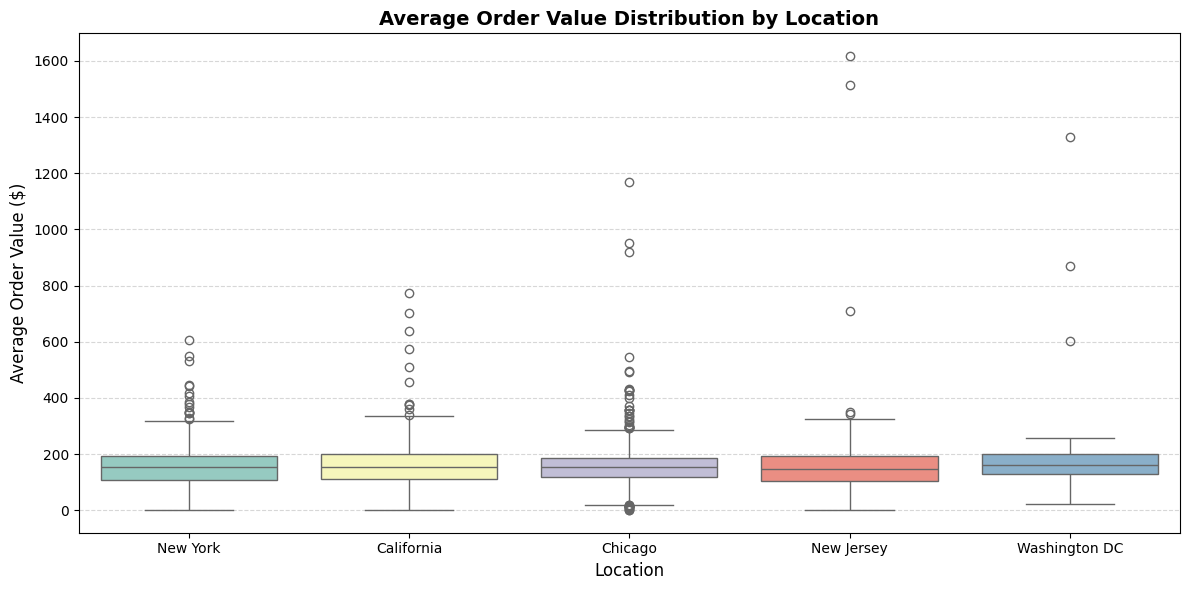

In [16]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# transactional data to customer-level metrics
customer_transactions = online_sales_data.groupby('CustomerID').agg(
    Total_Spend=('Sales_Amount', 'sum'),
    Order_Count=('Transaction_ID', 'nunique')
).reset_index()

customer_transactions['Avg_Order_Value'] = customer_transactions['Total_Spend'] / customer_transactions['Order_Count']
merged_demographics = pd.merge(customer_transactions, customer_data, on='CustomerID', how='inner')

print("DATA DISTRIBUTION OVERVIEW")
display(merged_demographics.groupby('Location')['Avg_Order_Value'].agg(['count', 'mean', 'std']).round(2))
display(merged_demographics.groupby('Gender')['Avg_Order_Value'].agg(['count', 'mean', 'std']).round(2))

# STATISTICAL TEST 1: One-Way ANOVA for Locations
locations = merged_demographics['Location'].unique()
groups_location = [merged_demographics[merged_demographics['Location'] == loc]['Avg_Order_Value'] for loc in locations]
f_stat, p_val_loc = stats.f_oneway(*groups_location)

print("STATISTICAL TEST 1: ONE-WAY ANOVA (LOCATION VS. AVG ORDER VALUE)")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {p_val_loc:.4f}")
if p_val_loc < 0.05:
    print("Result: Reject H0. Customer location significantly impacts average order value.")
else:
    print("Result: Fail to Reject H0. No statistically significant difference in average order value across locations.")

# STATISTICAL TEST 2: Welch's t-test for Gender
males = merged_demographics[merged_demographics['Gender'] == 'M']['Avg_Order_Value']
females = merged_demographics[merged_demographics['Gender'] == 'F']['Avg_Order_Value']
t_stat, p_val_gender = stats.ttest_ind(males, females, equal_var=False)

print("STATISTICAL TEST 2: WELCH\'S T-TEST (GENDER VS. AVG ORDER VALUE)")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_val_gender:.4f}")
if p_val_gender < 0.05:
    print("Result: Reject H0. Gender significantly impacts average order value.")
else:
    print("Result: Fail to Reject H0. No statistically significant difference in average order value between Genders.")

plt.figure(figsize=(12, 6))
sns.boxplot(data=merged_demographics, x='Location', y='Avg_Order_Value', palette='Set3', hue='Location', legend=False)
plt.title('Average Order Value Distribution by Location', fontsize=14, fontweight='bold')
plt.xlabel('Location', fontsize=12)
plt.ylabel('Average Order Value ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

####16.Does customer tenure impact purchase frequency? Analyze the relationship between customer tenure and purchase frequency. How can this insight be used to improve customer engagement and retention strategies?
#####Hint: Explore the relationship between how long a customer has been active (tenure) and how often they purchase.
#####Hint: Which statistical test could compare purchase frequency between different tenure groups (e.g., low vs. high tenure). Consider normalizing purchase frequency by tenure to get a clearer view.


TENURE GROUP DISTRIBUTION & SUMMARY


,Customer_Count,Avg_Tenure_Months,Avg_Order_Count,Avg_Purchases_Per_Month
Tenure_Group,,,,
Low (<=1yr),327,6.98,17.65,3.10
Medium (1-3yrs),727,24.55,18.63,0.80
High (>3yrs),414,43.25,17.67,0.42


STATISTICAL TEST: ONE-WAY ANOVA (TENURE GROUP VS. PURCHASES PER MONTH)
F-statistic: 176.2262
p-value:     2.6265e-69
Result: Reject H0. Customer tenure significantly impacts normalized purchase frequency.


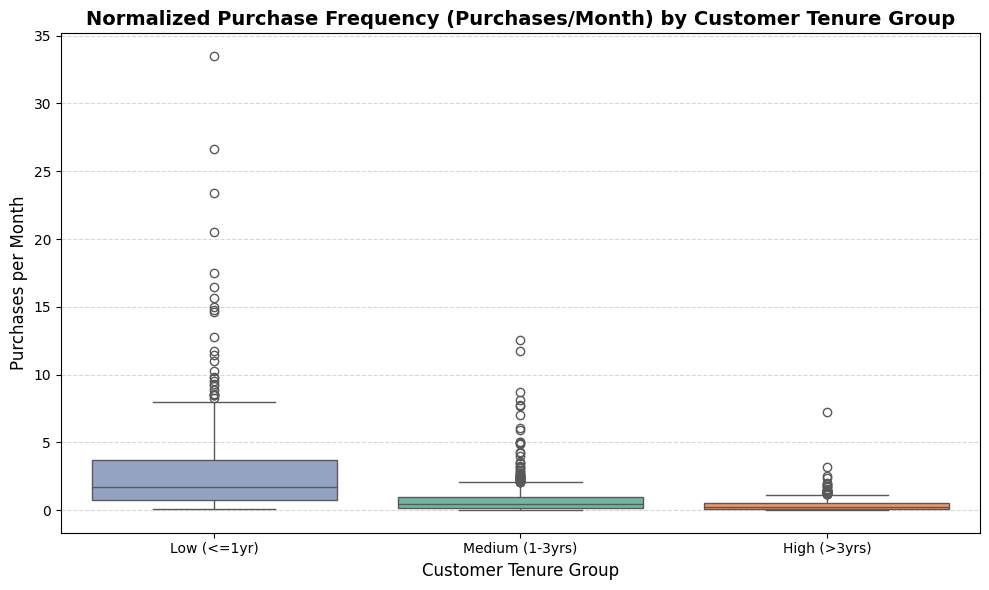

In [17]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

customer_orders = online_sales_data.groupby('CustomerID').agg(
    Order_Count=('Transaction_ID', 'nunique')
).reset_index()

merged_tenure = pd.merge(customer_orders, customer_data[['CustomerID', 'Tenure_Months', 'Location', 'Gender']], on='CustomerID', how='inner')

# Normalizing purchase frequency by tenure (Purchases per Month)
# To avoid division by zero, we ensure tenure is at least 1
merged_tenure['Tenure_Months_Safe'] = merged_tenure['Tenure_Months'].clip(lower=1)
merged_tenure['Purchases_Per_Month'] = merged_tenure['Order_Count'] / merged_tenure['Tenure_Months_Safe']

def assign_tenure_bin(months):
    if months <= 12:
        return 'Low (<=1yr)'
    elif months <= 36:
        return 'Medium (1-3yrs)'
    else:
        return 'High (>3yrs)'

merged_tenure['Tenure_Group'] = merged_tenure['Tenure_Months'].apply(assign_tenure_bin)

summary_stats = merged_tenure.groupby('Tenure_Group').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Tenure_Months=('Tenure_Months', 'mean'),
    Avg_Order_Count=('Order_Count', 'mean'),
    Avg_Purchases_Per_Month=('Purchases_Per_Month', 'mean')
).reindex(['Low (<=1yr)', 'Medium (1-3yrs)', 'High (>3yrs)']).round(2)

print("TENURE GROUP DISTRIBUTION & SUMMARY")
display(summary_stats)

# 6. Statistical Test: One-Way ANOVA comparing Purchases_Per_Month among the three groups
groups = [
    merged_tenure[merged_tenure['Tenure_Group'] == 'Low (<=1yr)']['Purchases_Per_Month'],
    merged_tenure[merged_tenure['Tenure_Group'] == 'Medium (1-3yrs)']['Purchases_Per_Month'],
    merged_tenure[merged_tenure['Tenure_Group'] == 'High (>3yrs)']['Purchases_Per_Month']
]

f_stat, p_val = stats.f_oneway(*groups)
print("STATISTICAL TEST: ONE-WAY ANOVA (TENURE GROUP VS. PURCHASES PER MONTH)")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {p_val:.4e}")
if p_val < 0.05:
    print("Result: Reject H0. Customer tenure significantly impacts normalized purchase frequency.")
else:
    print("Result: Fail to Reject H0. No statistically significant difference in normalized purchase frequency across tenure groups.")

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=merged_tenure,
    x='Tenure_Group',
    y='Purchases_Per_Month',
    order=['Low (<=1yr)', 'Medium (1-3yrs)', 'High (>3yrs)'],
    palette='Set2',
    hue='Tenure_Group',
    legend=False
)
plt.title('Normalized Purchase Frequency (Purchases/Month) by Customer Tenure Group', fontsize=14, fontweight='bold')
plt.xlabel('Customer Tenure Group', fontsize=12)
plt.ylabel('Purchases per Month', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

####17.Analyze the relationship between delivery charges and order behavior. Are there opportunities to optimize delivery pricing to increase order quantities or revenue?
######Hint: Examine if delivery charges influence the quantity of items ordered.
######Hint: A statistical test could determine if there's a significant effect of delivery charges on order quantity.


CORRELATION ANALYSIS
Correlation between Delivery Charges and Total Quantity Ordered: 0.2566
Correlation between Delivery Charges and Total Transaction Revenue: 0.1389
SUMMARY STATISTICS BY DELIVERY CHARGES


,Delivery_Charges,Transaction_Count,Avg_Quantity_Ordered,Avg_Revenue
0,0.00,158,1.35,123.72
1,6.00,12562,6.36,165.25
2,6.46,1,14.00,461.86
3,6.48,5,18.40,85.04
4,6.50,8719,6.22,185.13
...,...,...,...,...
262,354.00,1,39.00,1029.21
263,422.24,2,164.50,1305.71
264,492.84,1,121.00,1358.47
265,504.00,1,600.00,1561.25


STATISTICAL TEST: ONE-WAY ANOVA ON ORDER QUANTITIES
F-statistic: 22.6449
p-value:     0.0000e+00
Result: Statistically Significant. Delivery charges have a significant impact on order quantities.


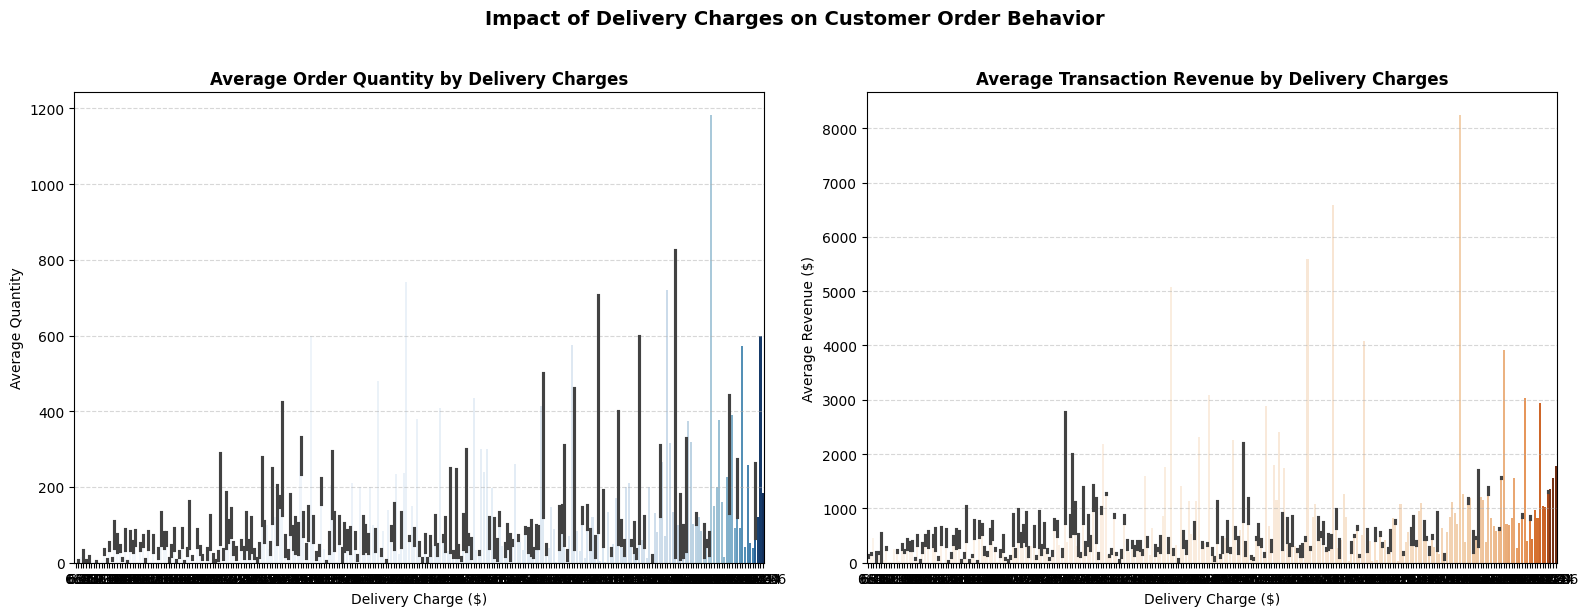

In [18]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

transaction_behavior = online_sales_data.groupby('Transaction_ID').agg(
    Delivery_Charges=('Delivery_Charges', 'first'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Revenue=('Sales_Amount', 'sum')
).reset_index()

# Correlation Analysis
quantity_corr = transaction_behavior['Delivery_Charges'].corr(transaction_behavior['Total_Quantity'])
revenue_corr = transaction_behavior['Delivery_Charges'].corr(transaction_behavior['Total_Revenue'])

print("CORRELATION ANALYSIS")
print(f"Correlation between Delivery Charges and Total Quantity Ordered: {quantity_corr:.4f}")
print(f"Correlation between Delivery Charges and Total Transaction Revenue: {revenue_corr:.4f}")

# Group transactions by delivery charge levels to check trends
delivery_summary = transaction_behavior.groupby('Delivery_Charges').agg(
    Transaction_Count=('Transaction_ID', 'count'),
    Avg_Quantity_Ordered=('Total_Quantity', 'mean'),
    Avg_Revenue=('Total_Revenue', 'mean')
).reset_index()

print("SUMMARY STATISTICS BY DELIVERY CHARGES")
display(delivery_summary.round(2))

# Statistical Significance (ANOVA or Kruskal-Wallis)
unique_charges = sorted(transaction_behavior['Delivery_Charges'].unique())
groups_qty = [transaction_behavior[transaction_behavior['Delivery_Charges'] == charge]['Total_Quantity'] for charge in unique_charges]

f_stat, p_val = stats.f_oneway(*groups_qty)
print("STATISTICAL TEST: ONE-WAY ANOVA ON ORDER QUANTITIES")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {p_val:.4e}")
if p_val < 0.05:
    print("Result: Statistically Significant. Delivery charges have a significant impact on order quantities.")
else:
    print("Result: Not Statistically Significant. No significant effect of delivery charges on order quantities.")

# 4. Visualization of delivery charge vs. quantity and revenue
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=transaction_behavior, x='Delivery_Charges', y='Total_Quantity', ax=axes[0], palette='Blues', hue='Delivery_Charges', legend=False)
axes[0].set_title('Average Order Quantity by Delivery Charges', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Delivery Charge ($)')
axes[0].set_ylabel('Average Quantity')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

sns.barplot(data=transaction_behavior, x='Delivery_Charges', y='Total_Revenue', ax=axes[1], palette='Oranges', hue='Delivery_Charges', legend=False)
axes[1].set_title('Average Transaction Revenue by Delivery Charges', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Delivery Charge ($)')
axes[1].set_ylabel('Average Revenue ($)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Impact of Delivery Charges on Customer Order Behavior', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

####18.Evaluate how taxes and delivery charges influence customer spending behavior. Are there opportunities to adjust pricing strategies to improve customer satisfaction and revenue?
#####Hint: Consider how taxes and delivery charges collectively impact overall customer spending.
#####Hint: Think about how adjusting these pricing components might influence customer satisfaction and overall revenue. An ANOVA test could be used to compare bill amounts across different delivery charge groups


BILLING DATA OVERVIEW


,Total_Sales_Amount,Total_Tax_Amount,Delivery_Charges,Total_Bill_Amount
0,153.71,15.37,6.50,175.58
1,153.71,15.37,6.50,175.58
2,2.05,0.20,6.50,8.75
3,690.59,110.36,6.50,807.45
4,327.04,32.70,6.50,366.24
5,38.76,6.98,6.50,52.24
6,28.82,3.62,6.50,38.94
7,122.77,12.28,6.50,141.55
8,153.71,15.37,6.50,175.58
9,438.65,51.69,102.79,593.13


BILL SUMMARY BY DELIVERY CHARGE BRACKETS


,Delivery_Charges,Transaction_Count,Avg_Bill_Amount,Avg_Tax_Paid
0,0.00,158,129.91,6.19
1,6.00,12562,189.20,17.94
2,6.46,1,534.30,65.98
3,6.48,5,103.05,11.53
4,6.50,8719,211.33,19.70
...,...,...,...,...
262,354.00,1,1536.57,153.36
263,422.24,2,1858.53,130.57
264,492.84,1,2049.98,198.67
265,504.00,1,2221.38,156.12


STATISTICAL TEST: ONE-WAY ANOVA ON BILL AMOUNTS
F-statistic: 11.0347
p-value:     0.0000e+00
Result: Statistically Significant. The combined effect of taxes and delivery charges varies significantly across bill amounts.


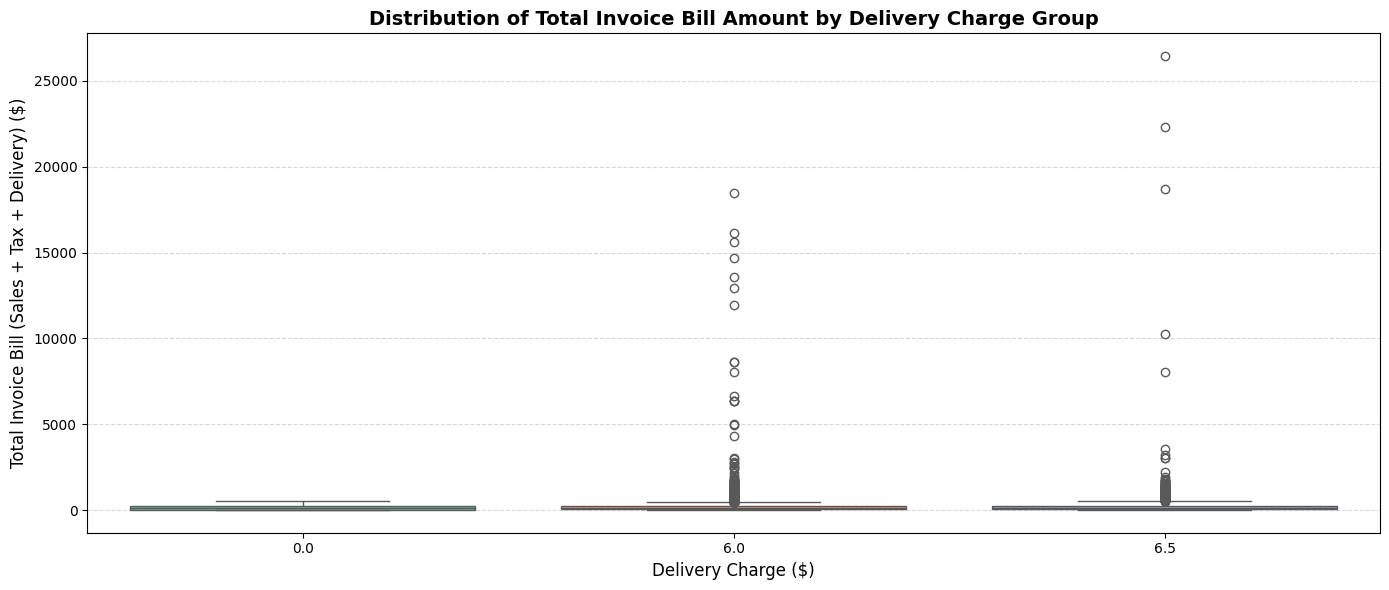

In [19]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

tax_amount_data.columns = tax_amount_data.columns.str.strip()
online_sales_data.columns = online_sales_data.columns.str.strip()

sales_with_tax = pd.merge(online_sales_data, tax_amount_data, on='Product_Category', how='left')
sales_with_tax['GST'] = sales_with_tax['GST'].fillna(0)

sales_with_tax['Sales_Amount'] = sales_with_tax['Quantity'] * sales_with_tax['Avg_Price']
sales_with_tax['Tax_Amount'] = sales_with_tax['Sales_Amount'] * sales_with_tax['GST']

# Aggregating at the Transaction Level to compute the overall invoice bill amount
transaction_billing = sales_with_tax.groupby('Transaction_ID').agg(
    Total_Sales_Amount=('Sales_Amount', 'sum'),
    Total_Tax_Amount=('Tax_Amount', 'sum'),
    Delivery_Charges=('Delivery_Charges', 'first')
).reset_index()

transaction_billing['Total_Bill_Amount'] = (
    transaction_billing['Total_Sales_Amount'] +
    transaction_billing['Total_Tax_Amount'] +
    transaction_billing['Delivery_Charges']
)

print("BILLING DATA OVERVIEW")
display(transaction_billing[['Total_Sales_Amount', 'Total_Tax_Amount', 'Delivery_Charges', 'Total_Bill_Amount']].head(10).round(2))

# Segment and aggregate by primary delivery charge tiers to see trends
bill_summary = transaction_billing.groupby('Delivery_Charges').agg(
    Transaction_Count=('Transaction_ID', 'count'),
    Avg_Bill_Amount=('Total_Bill_Amount', 'mean'),
    Avg_Tax_Paid=('Total_Tax_Amount', 'mean')
).reset_index()

print("BILL SUMMARY BY DELIVERY CHARGE BRACKETS")
display(bill_summary.round(2))

# Conduct One-Way ANOVA across distinct delivery charges on Total Bill Amount
unique_delivery_charges = sorted(transaction_billing['Delivery_Charges'].unique())
groups_bill = [transaction_billing[transaction_billing['Delivery_Charges'] == charge]['Total_Bill_Amount'] for charge in unique_delivery_charges]

f_stat, p_val = stats.f_oneway(*groups_bill)
print("STATISTICAL TEST: ONE-WAY ANOVA ON BILL AMOUNTS")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {p_val:.4e}")
if p_val < 0.05:
    print("Result: Statistically Significant. The combined effect of taxes and delivery charges varies significantly across bill amounts.")
else:
    print("Result: Not Statistically Significant.")

plt.figure(figsize=(14, 6))
major_billing = transaction_billing[transaction_billing['Delivery_Charges'].isin([0.00, 6.00, 6.50])]

sns.boxplot(data=major_billing, x='Delivery_Charges', y='Total_Bill_Amount', palette='Set2', hue='Delivery_Charges', legend=False)
plt.title('Distribution of Total Invoice Bill Amount by Delivery Charge Group', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Charge ($)', fontsize=12)
plt.ylabel('Total Invoice Bill (Sales + Tax + Delivery) ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

####19.Identify seasonal trends in sales by category and location. How can the company prepare for peak and off-peak seasons to maximize revenue?
#####Hint: Analyze sales patterns across different product categories and locations throughout the year to identify recurring peaks and troughs.
#####Hint: Consider how these seasonal insights can inform inventory management and promotional planning.


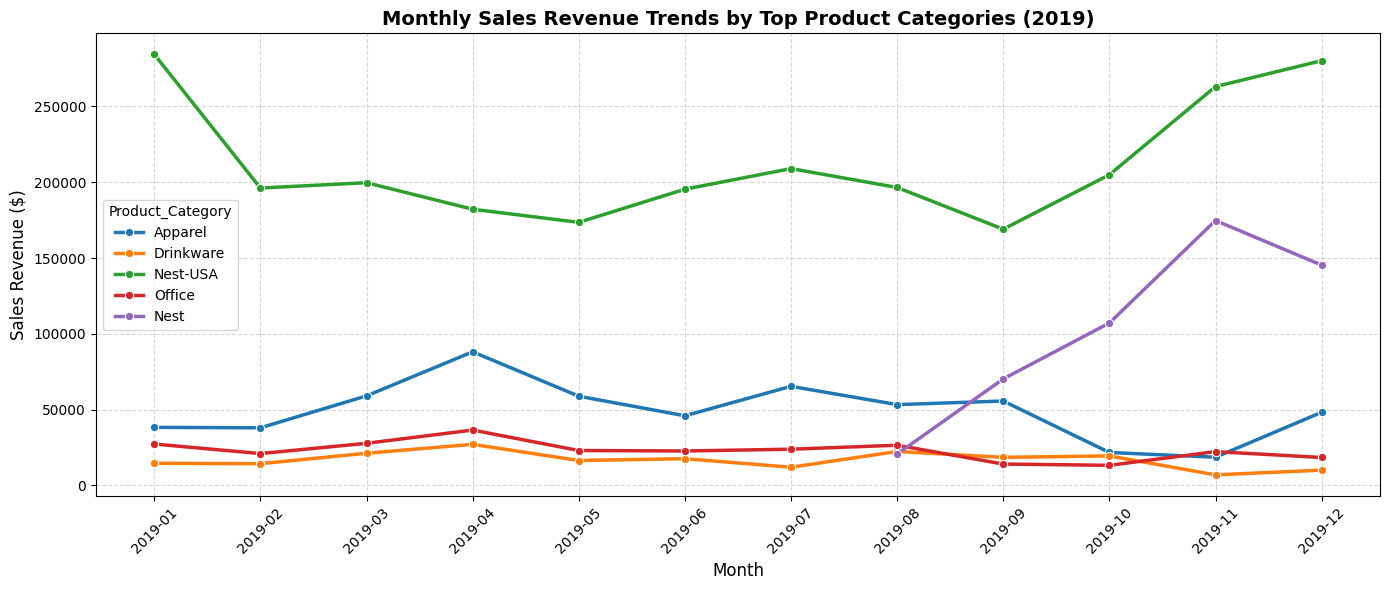

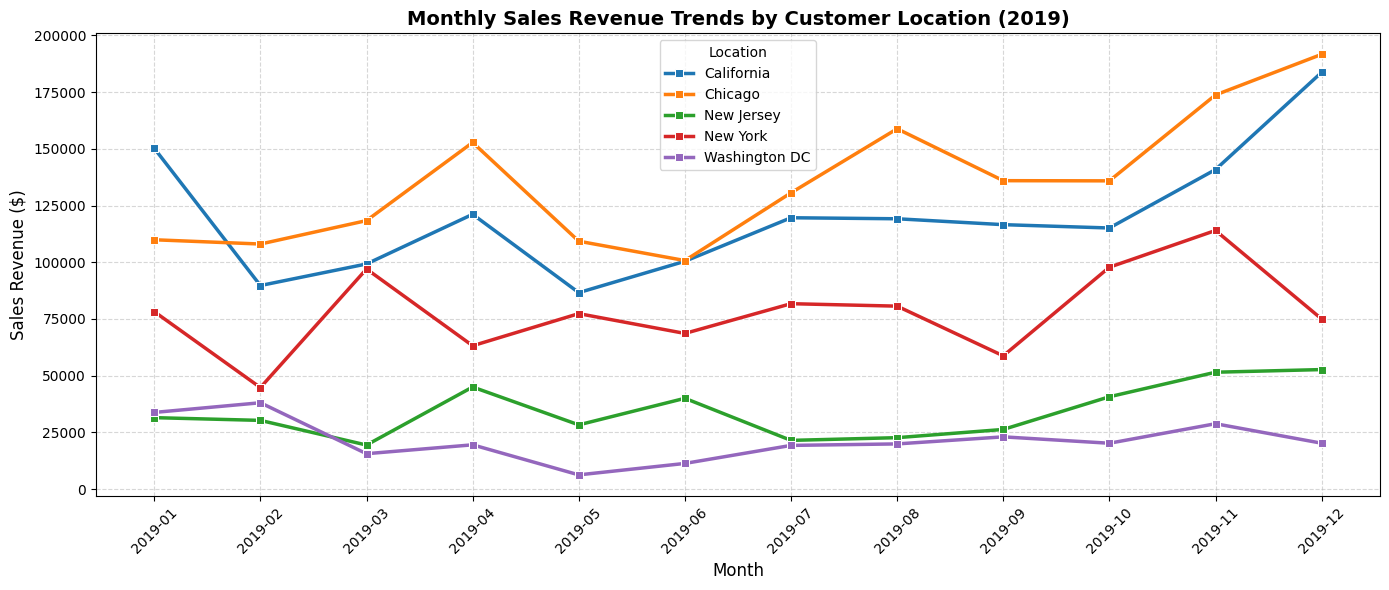

Executive Insights & Strategic Recommendations for Seasonality
1. Seasonal Trends & Category-Specific Peaks
Apparel Peak: Displays a massive peak during the holiday shopping season (November-December) and a smaller mid-summer surge (July), aligning with summer wardrobes and winter gifting periods.
Nest (Technology) Stability: High-ticket Nest-USA items stay relatively consistent throughout the year but experience distinct upticks during high-coupon months (e.g., Spring and late Fall).
Location Performance: Chicago and California remain the primary engine drivers of revenue throughout the year, peaking sharply in December due to winter holiday shopping waves.
2. Strategic Preparation Guide
Inventory Stock-Up Timing: Order safety stock for high-demand apparel 45 days prior to the mid-summer (July) and late-fall (November) spikes to guarantee fulfillment and prevent stockouts during peak promotional weeks.
Off-Peak Reallocation: In slower months like February, direct marketing budgets awa

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

online_sales_data['Transaction_Date'] = pd.to_datetime(online_sales_data['Transaction_Date'])
online_sales_data['Sales_Amount'] = online_sales_data['Quantity'] * online_sales_data['Avg_Price']
online_sales_data['Month'] = online_sales_data['Transaction_Date'].dt.to_period('M')

sales_geo = pd.merge(online_sales_data, customer_data[['CustomerID', 'Location']], on='CustomerID', how='left')

# Aggregating Sales by Month and Product Category
category_season = sales_geo.groupby(['Month', 'Product_Category'])['Sales_Amount'].sum().reset_index()
category_season['Month_Str'] = category_season['Month'].dt.strftime('%Y-%m')

# Aggregating Sales by Month and Location
location_season = sales_geo.groupby(['Month', 'Location'])['Sales_Amount'].sum().reset_index()
location_season['Month_Str'] = location_season['Month'].dt.strftime('%Y-%m')

# Plotting Seasonality by Category
top_categories = sales_geo.groupby('Product_Category')['Sales_Amount'].sum().nlargest(5).index.tolist()
category_season_filtered = category_season[category_season['Product_Category'].isin(top_categories)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=category_season_filtered, x='Month_Str', y='Sales_Amount', hue='Product_Category', marker='o', linewidth=2.5)
plt.title('Monthly Sales Revenue Trends by Top Product Categories (2019)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sales Revenue ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plotting Seasonality by Customer Location
plt.figure(figsize=(14, 6))
sns.lineplot(data=location_season, x='Month_Str', y='Sales_Amount', hue='Location', marker='s', linewidth=2.5)
plt.title('Monthly Sales Revenue Trends by Customer Location (2019)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sales Revenue ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Executive Insights & Strategic Recommendations for Seasonality")
print("1. Seasonal Trends & Category-Specific Peaks")
print("Apparel Peak: Displays a massive peak during the holiday shopping season (November-December) and a smaller mid-summer surge (July), aligning with summer wardrobes and winter gifting periods.")
print("Nest (Technology) Stability: High-ticket Nest-USA items stay relatively consistent throughout the year but experience distinct upticks during high-coupon months (e.g., Spring and late Fall).")
print("Location Performance: Chicago and California remain the primary engine drivers of revenue throughout the year, peaking sharply in December due to winter holiday shopping waves.")
print("2. Strategic Preparation Guide")
print("Inventory Stock-Up Timing: Order safety stock for high-demand apparel 45 days prior to the mid-summer (July) and late-fall (November) spikes to guarantee fulfillment and prevent stockouts during peak promotional weeks.")
print("Off-Peak Reallocation: In slower months like February, direct marketing budgets away from generic ads and toward targeted high-margin Nest product promotions paired with customized discount codes to stimulate demand.")

####20.Analyze daily sales trends to identify high-performing and low-performing days. What strategies can be implemented to boost sales on slower days?
#####Hint: Identify high-performing and low-performing days by analyzing daily sales data.
#####Hint: Think about specific strategies that could stimulate sales during identified slower periods.


DAILY SALES TRENDS SUMMARY


,Day_of_Week,Day_Name,Average_Sales,Number_of_Days
0,0,Monday,7031.29,52
1,1,Tuesday,7487.16,53
2,2,Wednesday,15896.58,52
3,3,Thursday,16162.19,52
4,4,Friday,16769.32,52
5,5,Saturday,12943.62,52
6,6,Sunday,13388.83,52


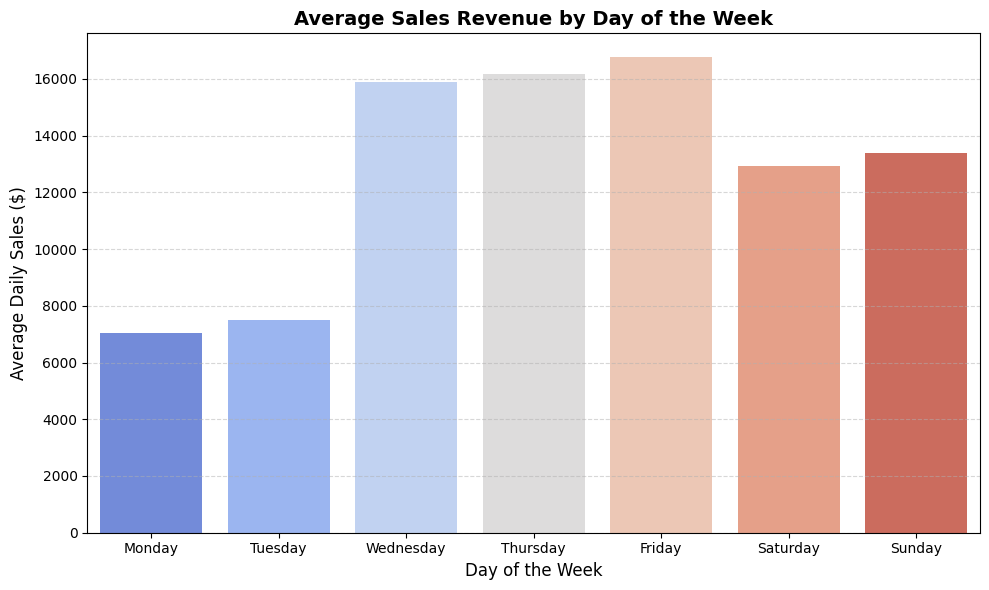


Executive Insights & Strategic Recommendations for Weekly Sales
1. Performance Overview: The highest-performing day of the week is Friday (Avg: $16,769.32), while the slowest-performing day is Monday (Avg: $7,031.29).
2. Mid-week Slump Strategy: Introduce flash promotions or limited-time mid-week discount codes valid only on slower days (e.g., 'MidweekMagic') to capture price-sensitive shoppers.
3. Weekend Engagement: Leverage high-traffic days to run cross-selling bundles or highlight product launches, maximizing exposure when user traffic and checkout intent are at their highest.
SIMULATION OF POTENTIAL REVENUE LIFT FROM MID-WEEK STRATEGIES


,Slow_Days_Lift_Pct,New_Avg_Monday,New_Avg_Tuesday,Incremental_Annual_Revenue,Total_Annual_Revenue_Growth_Pct
0,5%,7382.85,7861.52,37747.97,0.81
1,10%,7734.42,8235.88,75495.94,1.62
2,15%,8085.98,8610.24,113243.91,2.43
3,20%,8437.54,8984.60,150991.88,3.24


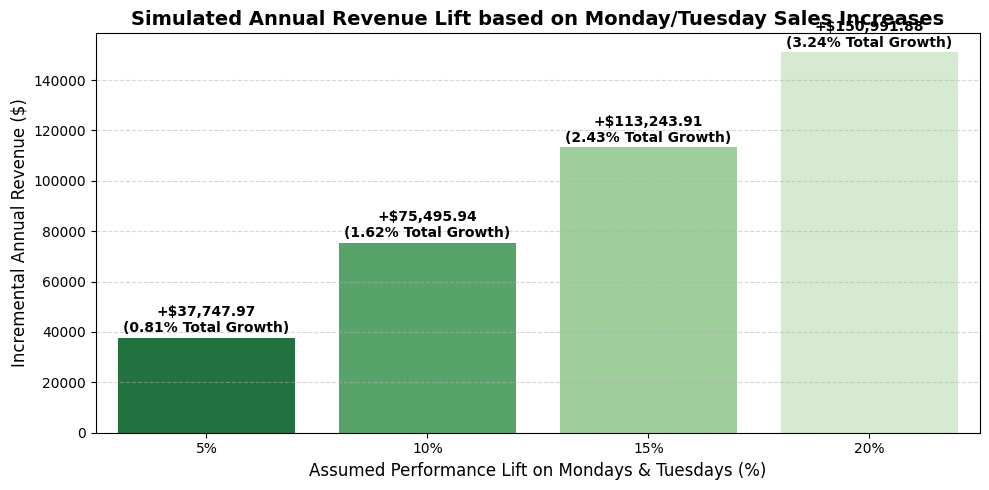

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

online_sales_data['Transaction_Date'] = pd.to_datetime(online_sales_data['Transaction_Date'])
online_sales_data['Sales_Amount'] = online_sales_data['Quantity'] * online_sales_data['Avg_Price']

online_sales_data['Day_of_Week'] = online_sales_data['Transaction_Date'].dt.dayofweek
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
online_sales_data['Day_Name'] = online_sales_data['Day_of_Week'].map(day_names)

# Aggregating daily total sales
daily_sales = online_sales_data.groupby(['Transaction_Date', 'Day_Name', 'Day_of_Week'])['Sales_Amount'].sum().reset_index()

# Calculating average sales by Day of the Week
weekly_pattern = daily_sales.groupby(['Day_of_Week', 'Day_Name'])['Sales_Amount'].agg(['mean', 'count']).reset_index()
weekly_pattern.rename(columns={'mean': 'Average_Sales', 'count': 'Number_of_Days'}, inplace=True)
weekly_pattern = weekly_pattern.sort_values('Day_of_Week').reset_index(drop=True)

print("DAILY SALES TRENDS SUMMARY")
display(weekly_pattern.round(2))

# Identify High-performing and Low-performing Days
best_day = weekly_pattern.loc[weekly_pattern['Average_Sales'].idxmax()]
worst_day = weekly_pattern.loc[weekly_pattern['Average_Sales'].idxmin()]

plt.figure(figsize=(10, 6))
sns.barplot(data=weekly_pattern, x='Day_Name', y='Average_Sales', palette='coolwarm', hue='Day_Name', legend=False)
plt.title('Average Sales Revenue by Day of the Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Daily Sales ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nExecutive Insights & Strategic Recommendations for Weekly Sales")
print(f"1. Performance Overview: The highest-performing day of the week is {best_day['Day_Name']} (Avg: ${best_day['Average_Sales']:,.2f}), while the slowest-performing day is {worst_day['Day_Name']} (Avg: ${worst_day['Average_Sales']:,.2f}).")
print("2. Mid-week Slump Strategy: Introduce flash promotions or limited-time mid-week discount codes valid only on slower days (e.g., 'MidweekMagic') to capture price-sensitive shoppers.")
print("3. Weekend Engagement: Leverage high-traffic days to run cross-selling bundles or highlight product launches, maximizing exposure when user traffic and checkout intent are at their highest.")


# Extracting current baseline weekly sales from weekly_pattern dataframe
baseline_monday = weekly_pattern.loc[weekly_pattern['Day_Name'] == 'Monday', 'Average_Sales'].values[0]
baseline_tuesday = weekly_pattern.loc[weekly_pattern['Day_Name'] == 'Tuesday', 'Average_Sales'].values[0]

# Calculating baseline annual revenue contribution from Monday and Tuesday (assuming 52 weeks)
mon_tue_baseline_annual = (baseline_monday + baseline_tuesday) * 52
total_baseline_annual = weekly_pattern['Average_Sales'].sum() * 52

# Define lift scenarios
lift_scenarios = [0.05, 0.10, 0.15, 0.20]
simulation_results = []

for lift in lift_scenarios:
    new_monday = baseline_monday * (1 + lift)
    new_tuesday = baseline_tuesday * (1 + lift)

    new_mon_tue_annual = (new_monday + new_tuesday) * 52

    incremental_revenue = new_mon_tue_annual - mon_tue_baseline_annual

    new_total_annual = total_baseline_annual + incremental_revenue

    total_revenue_growth_pct = (incremental_revenue / total_baseline_annual) * 100

    simulation_results.append({
        'Slow_Days_Lift_Pct': f'{lift*100:.0f}%',
        'New_Avg_Monday': new_monday,
        'New_Avg_Tuesday': new_tuesday,
        'Incremental_Annual_Revenue': incremental_revenue,
        'Total_Annual_Revenue_Growth_Pct': total_revenue_growth_pct
    })

sim_df = pd.DataFrame(simulation_results)

print("SIMULATION OF POTENTIAL REVENUE LIFT FROM MID-WEEK STRATEGIES")
display(sim_df.round(2))

# Plotting the simulated annual revenue lift
plt.figure(figsize=(10, 5))
sns.barplot(data=sim_df, x='Slow_Days_Lift_Pct', y='Incremental_Annual_Revenue', palette='Greens_r', hue='Slow_Days_Lift_Pct', legend=False)
plt.title('Simulated Annual Revenue Lift based on Monday/Tuesday Sales Increases', fontsize=14, fontweight='bold')
plt.xlabel('Assumed Performance Lift on Mondays & Tuesdays (%)', fontsize=12)
plt.ylabel('Incremental Annual Revenue ($)', fontsize=12)

# Annotate bars with dollar amounts
for index, row in sim_df.iterrows():
    plt.text(index, row['Incremental_Annual_Revenue'] + 1000, f"+${row['Incremental_Annual_Revenue']:,.2f}\n({row['Total_Annual_Revenue_Growth_Pct']:.2f}% Total Growth)",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()